# 🧠 Cérebro Artificial Modular: Emoções e Marcadores Somáticos

## Teoria Base

### Paul Ekman → Emoções Básicas
Paul Ekman identificou **6 emoções universais** reconhecidas em todas as culturas:
- 😊 **Felicidade** (Happy)
- 😢 **Tristeza** (Sadness)
- 😠 **Raiva** (Anger)
- 😨 **Medo** (Fear)
- 😲 **Surpresa** (Surprise)
- 😖 **Nojo** (Disgust)

### Antonio Damasio → Marcadores Somáticos
Antonio Damasio propôs que as **emoções são estados corporais** que guiam a tomada de decisão:
- **Marcadores somáticos** = estados fisiológicos internos
- **Dopamina**: prazer, recompensa, motivação
- **Cortisol**: estresse, ameaça, alerta
- **Serotonina**: bem-estar, interação social, humor

---

## 🏗️ Arquitetura do Cérebro Artificial

```
ENTRADA → Amígdala → Sistema de Recompensa → Memória → Emoção Final
           ↓              ↓                    ↓           ↓
        Cortisol      Dopamina            LSTM/RNN    Classificação
```

### Módulos:

1. **🔴 Amígdala** (Sistema de ameaça)
   - Detecta perigo/estresse
   - Atualiza **cortisol**

2. **🟢 Sistema de Recompensa** (Dopamina)
   - Detecta recompensas
   - Atualiza **dopamina**

3. **🟡 Marcadores Somáticos** (Damasio)
   - Estados corporais internos
   - Dopamina, Cortisol, Serotonina

4. **🔵 Memória Emocional** (RNN/LSTM)
   - Guarda experiências passadas
   - Processa sequências temporais


## 📦 Instalação e Imports


In [58]:
# Instalar dependências (execute apenas uma vez)
# !pip install torch matplotlib numpy seaborn

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo
plt.style.use('dark_background')
sns.set_palette("husl")

print("✅ Bibliotecas importadas com sucesso!")
print(f"🔥 PyTorch versão: {torch.__version__}")
print(f"📊 NumPy versão: {np.__version__}")


✅ Bibliotecas importadas com sucesso!
🔥 PyTorch versão: 2.9.0+cpu
📊 NumPy versão: 1.26.4


## 🧠 Modelo: CerebroEmocional

### Estrutura do Modelo:

1. **Estados Internos** (Marcadores Somáticos):
   - `dopamina`: prazer e recompensa
   - `cortisol`: estresse e ameaça
   - `serotonina`: bem-estar social

2. **Memória Emocional** (LSTM):
   - Processa sequências temporais de estados
   - Hidden size: 8 neurônios

3. **Decisor Emocional** (Linear):
   - Mapeia memória → emoções de Ekman


In [59]:
# Emoções básicas de Ekman (adaptadas)
EMOCOES = ["feliz", "triste", "raiva", "medo", "surpresa", "neutro"]
EMOCOES_EMOJI = ["😊", "😢", "😠", "😨", "😲", "😐"]

class CerebroEmocional(nn.Module):
    """
    Cérebro Artificial Modular baseado em:
    - Paul Ekman (emoções básicas)
    - Antonio Damasio (marcadores somáticos)
    """
    
    def __init__(self, hidden_size=8, num_emocoes=6):
        super(CerebroEmocional, self).__init__()
        
        # Estados internos (marcadores somáticos de Damasio)
        self.dopamina = 0.0
        self.cortisol = 0.0
        self.serotonina = 0.0
        
        # Taxas de decaimento (simula metabolismo)
        self.decay_dopamina = 0.1
        self.decay_cortisol = 0.1
        self.decay_serotonina = 0.05
        
        # Memória emocional (LSTM - simula hipocampo)
        self.lstm = nn.LSTM(
            input_size=3,      # 3 marcadores somáticos
            hidden_size=hidden_size,
            batch_first=True,
            num_layers=1
        )
        
        # Decisor emocional (simula córtex pré-frontal)
        self.fc = nn.Linear(hidden_size, num_emocoes)
        
        # Histórico para visualização
        self.historico = {
            'dopamina': [],
            'cortisol': [],
            'serotonina': [],
            'emocoes': []
        }
    
    def atualizar_estado(self, recompensa=0.0, ameaca=0.0, social=0.0):
        """
        Atualiza os marcadores somáticos baseado em eventos.
        
        Parâmetros:
        - recompensa: valor positivo aumenta dopamina
        - ameaca: valor positivo aumenta cortisol
        - social: valor positivo aumenta serotonina
        """
        # Atualização dinâmica (Damasio)
        # Dopamina: recompensa - decaimento natural
        self.dopamina += recompensa - self.decay_dopamina * self.dopamina
        self.dopamina = max(0.0, min(10.0, self.dopamina))  # Limita entre 0-10
        
        # Cortisol: ameaça - decaimento natural
        self.cortisol += ameaca - self.decay_cortisol * self.cortisol
        self.cortisol = max(0.0, min(10.0, self.cortisol))
        
        # Serotonina: interação social - decaimento natural
        self.serotonina += social - self.decay_serotonina * self.serotonina
        self.serotonina = max(0.0, min(10.0, self.serotonina))
        
        # Salva histórico
        self.historico['dopamina'].append(self.dopamina)
        self.historico['cortisol'].append(self.cortisol)
        self.historico['serotonina'].append(self.serotonina)
    
    def forward(self):
        """
        Processa os estados internos através da memória LSTM
        e retorna a emoção prevista.
        """
        # Prepara entrada: [batch, seq_len, features]
        estado = torch.tensor([[[
            self.dopamina,
            self.cortisol,
            self.serotonina
        ]]], dtype=torch.float32)
        
        # Processa através da LSTM (memória emocional)
        lstm_out, _ = self.lstm(estado)
        
        # Última saída da sequência
        ultima_saida = lstm_out[:, -1, :]
        
        # Decisão emocional (córtex pré-frontal)
        output = self.fc(ultima_saida)
        
        return output
    
    def prever_emocao(self):
        """Retorna a emoção prevista e suas probabilidades."""
        with torch.no_grad():
            output = self.forward()
            probs = torch.softmax(output, dim=1)
            emocao_idx = torch.argmax(probs, dim=1).item()
            
            return {
                'emocao': EMOCOES[emocao_idx],
                'emoji': EMOCOES_EMOJI[emocao_idx],
                'probabilidades': probs[0].numpy(),
                'estados': {
                    'dopamina': self.dopamina,
                    'cortisol': self.cortisol,
                    'serotonina': self.serotonina
                }
            }
    
    def reset(self):
        """Reseta os estados internos e histórico."""
        self.dopamina = 0.0
        self.cortisol = 0.0
        self.serotonina = 0.0
        self.historico = {
            'dopamina': [],
            'cortisol': [],
            'serotonina': [],
            'emocoes': []
        }

print("✅ Classe CerebroEmocional definida!")


✅ Classe CerebroEmocional definida!


## 🧪 Simulação 1: Eventos Básicos

Vamos simular diferentes eventos e observar como o cérebro reage emocionalmente.


In [60]:
# Criar instância do cérebro
cerebro = CerebroEmocional()

# Definir eventos de simulação
eventos = [
    {"nome": "Recebeu presente", "recompensa": 2.0, "ameaca": 0.0, "social": 1.0},
    {"nome": "Encontrou amigo", "recompensa": 1.0, "ameaca": 0.0, "social": 2.0},
    {"nome": "Viu predador", "recompensa": 0.0, "ameaca": 3.0, "social": 0.0},
    {"nome": "Conflito social", "recompensa": 0.0, "ameaca": 2.0, "social": -1.0},
    {"nome": "Vitória em jogo", "recompensa": 3.0, "ameaca": 0.0, "social": 1.5},
]

print("🧠 Simulação do Cérebro Emocional\n")
print("=" * 60)

for i, evento in enumerate(eventos, 1):
    # Atualizar estados internos
    cerebro.atualizar_estado(
        recompensa=evento["recompensa"],
        ameaca=evento["ameaca"],
        social=evento["social"]
    )
    
    # Prever emoção
    resultado = cerebro.prever_emocao()
    
    print(f"\n📅 Evento {i}: {evento['nome']}")
    print(f"   Entrada: Recompensa={evento['recompensa']:.1f}, "
          f"Ameaça={evento['ameaca']:.1f}, Social={evento['social']:.1f}")
    print(f"\n   🧬 Estados Internos (Marcadores Somáticos):")
    print(f"      Dopamina:  {resultado['estados']['dopamina']:.2f}")
    print(f"      Cortisol:  {resultado['estados']['cortisol']:.2f}")
    print(f"      Serotonina: {resultado['estados']['serotonina']:.2f}")
    print(f"\n   {resultado['emoji']} Emoção Prevista: {resultado['emocao'].upper()}")
    print(f"   📊 Probabilidades:")
    for emo, prob in zip(EMOCOES, resultado['probabilidades']):
        barra = "█" * int(prob * 20)
        print(f"      {emo:10s}: {prob*100:5.1f}% {barra}")
    print("-" * 60)


🧠 Simulação do Cérebro Emocional


📅 Evento 1: Recebeu presente
   Entrada: Recompensa=2.0, Ameaça=0.0, Social=1.0

   🧬 Estados Internos (Marcadores Somáticos):
      Dopamina:  2.00
      Cortisol:  0.00
      Serotonina: 1.00

   😨 Emoção Prevista: MEDO
   📊 Probabilidades:
      feliz     :  14.8% ██
      triste    :  13.7% ██
      raiva     :  15.7% ███
      medo      :  21.1% ████
      surpresa  :  16.7% ███
      neutro    :  18.0% ███
------------------------------------------------------------

📅 Evento 2: Encontrou amigo
   Entrada: Recompensa=1.0, Ameaça=0.0, Social=2.0

   🧬 Estados Internos (Marcadores Somáticos):
      Dopamina:  2.80
      Cortisol:  0.00
      Serotonina: 2.95

   😨 Emoção Prevista: MEDO
   📊 Probabilidades:
      feliz     :  14.9% ██
      triste    :  12.9% ██
      raiva     :  16.1% ███
      medo      :  22.1% ████
      surpresa  :  17.2% ███
      neutro    :  16.7% ███
------------------------------------------------------------

📅 Evento 3

## 📊 Visualização: Evolução dos Estados Internos


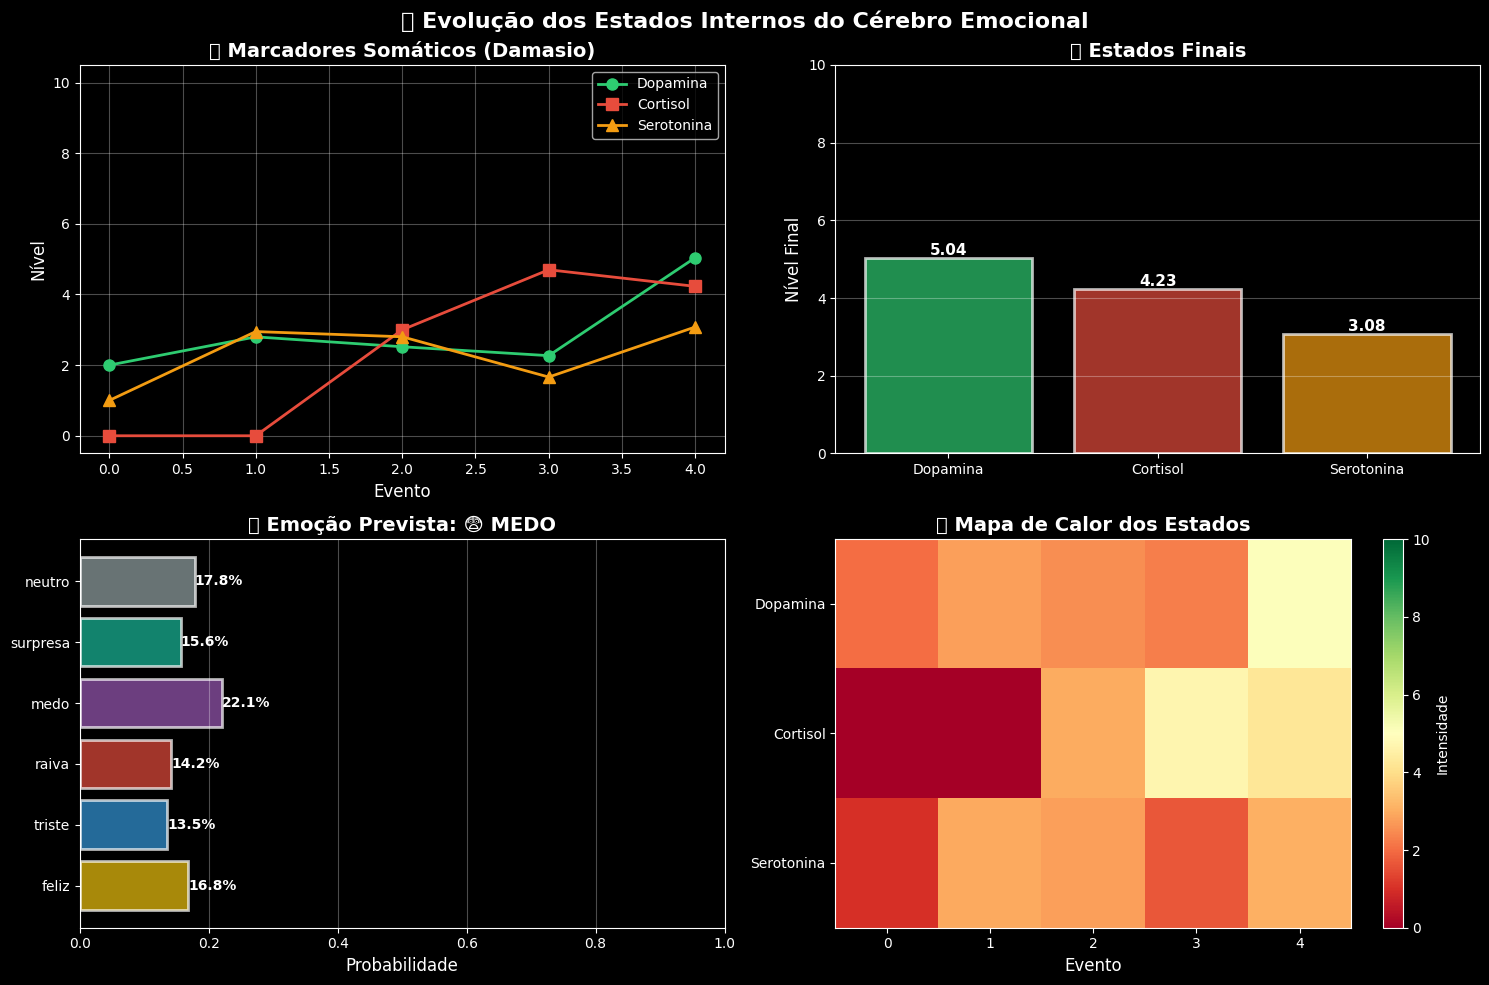

✅ Visualizações geradas!


In [61]:
# Criar figura com subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🧠 Evolução dos Estados Internos do Cérebro Emocional', 
             fontsize=16, fontweight='bold')

# Gráfico 1: Marcadores Somáticos ao longo do tempo
ax1 = axes[0, 0]
tempo = range(len(cerebro.historico['dopamina']))
ax1.plot(tempo, cerebro.historico['dopamina'], 'o-', label='Dopamina', 
         color='#2ecc71', linewidth=2, markersize=8)
ax1.plot(tempo, cerebro.historico['cortisol'], 's-', label='Cortisol', 
         color='#e74c3c', linewidth=2, markersize=8)
ax1.plot(tempo, cerebro.historico['serotonina'], '^-', label='Serotonina', 
         color='#f39c12', linewidth=2, markersize=8)
ax1.set_xlabel('Evento', fontsize=12)
ax1.set_ylabel('Nível', fontsize=12)
ax1.set_title('📈 Marcadores Somáticos (Damasio)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.5, 10.5)

# Gráfico 2: Comparação dos estados finais
ax2 = axes[0, 1]
estados_finais = [
    cerebro.historico['dopamina'][-1],
    cerebro.historico['cortisol'][-1],
    cerebro.historico['serotonina'][-1]
]
cores = ['#2ecc71', '#e74c3c', '#f39c12']
barras = ax2.bar(['Dopamina', 'Cortisol', 'Serotonina'], estados_finais, 
                 color=cores, alpha=0.7, edgecolor='white', linewidth=2)
ax2.set_ylabel('Nível Final', fontsize=12)
ax2.set_title('🎯 Estados Finais', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 10)
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for barra, valor in zip(barras, estados_finais):
    altura = barra.get_height()
    ax2.text(barra.get_x() + barra.get_width()/2., altura,
             f'{valor:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 3: Probabilidades das emoções (último evento)
ax3 = axes[1, 0]
resultado_final = cerebro.prever_emocao()
probabilidades = resultado_final['probabilidades']
cores_emo = ['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6']
barras_emo = ax3.barh(EMOCOES, probabilidades, color=cores_emo, alpha=0.7, 
                      edgecolor='white', linewidth=2)
ax3.set_xlabel('Probabilidade', fontsize=12)
ax3.set_title(f'🎭 Emoção Prevista: {resultado_final["emoji"]} {resultado_final["emocao"].upper()}', 
              fontsize=14, fontweight='bold')
ax3.set_xlim(0, 1)
ax3.grid(True, alpha=0.3, axis='x')

# Adicionar valores nas barras
for barra, prob in zip(barras_emo, probabilidades):
    largura = barra.get_width()
    ax3.text(largura, barra.get_y() + barra.get_height()/2.,
             f'{prob*100:.1f}%',
             ha='left', va='center', fontsize=10, fontweight='bold', 
             color='white' if largura < 0.3 else 'black')

# Gráfico 4: Mapa de calor dos estados ao longo do tempo
ax4 = axes[1, 1]
dados_heatmap = np.array([
    cerebro.historico['dopamina'],
    cerebro.historico['cortisol'],
    cerebro.historico['serotonina']
])
im = ax4.imshow(dados_heatmap, aspect='auto', cmap='RdYlGn', 
                interpolation='nearest', vmin=0, vmax=10)
ax4.set_yticks([0, 1, 2])
ax4.set_yticklabels(['Dopamina', 'Cortisol', 'Serotonina'])
ax4.set_xlabel('Evento', fontsize=12)
ax4.set_title('🔥 Mapa de Calor dos Estados', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Intensidade')

plt.tight_layout()
plt.show()

print("✅ Visualizações geradas!")


## 🧪 Simulação 2: Cenário Narrativo

Vamos simular uma história completa e ver como o cérebro evolui emocionalmente.


In [62]:
# Resetar o cérebro
cerebro.reset()

# História: Um dia na vida do cérebro
historia = [
    {"evento": "Acordou descansado", "recompensa": 0.5, "ameaca": 0.0, "social": 0.0},
    {"evento": "Tomou café da manhã", "recompensa": 1.0, "ameaca": 0.0, "social": 0.0},
    {"evento": "Conversou com família", "recompensa": 0.5, "ameaca": 0.0, "social": 2.0},
    {"evento": "Chegou atrasado no trabalho", "recompensa": 0.0, "ameaca": 1.5, "social": -0.5},
    {"evento": "Chefe reclamou", "recompensa": 0.0, "ameaca": 2.0, "social": -1.0},
    {"evento": "Almoçou com colegas", "recompensa": 1.0, "ameaca": 0.0, "social": 1.5},
    {"evento": "Conseguiu resolver problema difícil", "recompensa": 2.5, "ameaca": 0.0, "social": 0.5},
    {"evento": "Recebeu elogio do chefe", "recompensa": 2.0, "ameaca": 0.0, "social": 1.0},
    {"evento": "Saiu com amigos", "recompensa": 1.5, "ameaca": 0.0, "social": 2.5},
    {"evento": "Voltou para casa relaxado", "recompensa": 1.0, "ameaca": 0.0, "social": 0.5},
]

print("📖 História: Um Dia na Vida do Cérebro Emocional\n")
print("=" * 70)

resultados_historia = []

for i, momento in enumerate(historia, 1):
    cerebro.atualizar_estado(
        recompensa=momento["recompensa"],
        ameaca=momento["ameaca"],
        social=momento["social"]
    )
    
    resultado = cerebro.prever_emocao()
    resultados_historia.append(resultado)
    
    print(f"{i:2d}. {momento['evento']:35s} → {resultado['emoji']} {resultado['emocao'].upper():10s} "
          f"(D:{resultado['estados']['dopamina']:.1f} "
          f"C:{resultado['estados']['cortisol']:.1f} "
          f"S:{resultado['estados']['serotonina']:.1f})")

print("\n" + "=" * 70)
print(f"\n🎯 Estado Final: {resultados_historia[-1]['emoji']} {resultados_historia[-1]['emocao'].upper()}")


📖 História: Um Dia na Vida do Cérebro Emocional

 1. Acordou descansado                  → 😨 MEDO       (D:0.5 C:0.0 S:0.0)
 2. Tomou café da manhã                 → 😨 MEDO       (D:1.4 C:0.0 S:0.0)
 3. Conversou com família               → 😨 MEDO       (D:1.8 C:0.0 S:2.0)
 4. Chegou atrasado no trabalho         → 😨 MEDO       (D:1.6 C:1.5 S:1.4)
 5. Chefe reclamou                      → 😨 MEDO       (D:1.5 C:3.4 S:0.3)
 6. Almoçou com colegas                 → 😨 MEDO       (D:2.3 C:3.0 S:1.8)
 7. Conseguiu resolver problema difícil → 😨 MEDO       (D:4.6 C:2.7 S:2.2)
 8. Recebeu elogio do chefe             → 😨 MEDO       (D:6.1 C:2.4 S:3.1)
 9. Saiu com amigos                     → 😨 MEDO       (D:7.0 C:2.2 S:5.5)
10. Voltou para casa relaxado           → 😨 MEDO       (D:7.3 C:2.0 S:5.7)


🎯 Estado Final: 😨 MEDO


## 📈 Visualização da História Completa


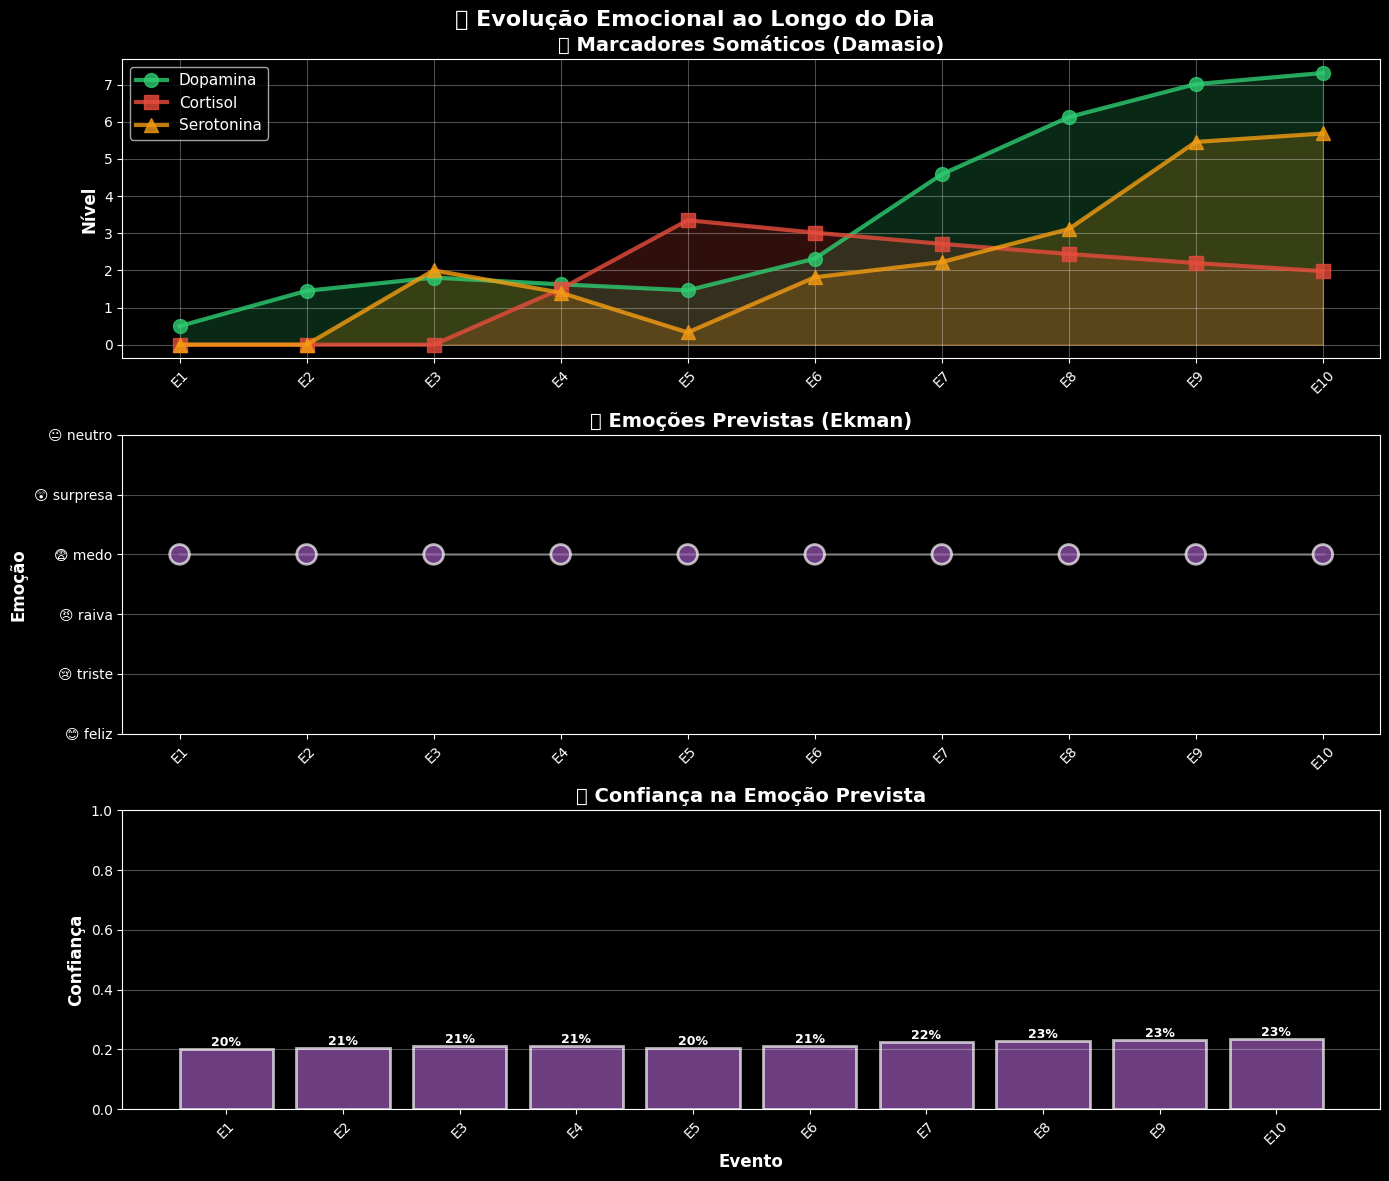

✅ Visualização da história completa gerada!


In [63]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('📖 Evolução Emocional ao Longo do Dia', 
             fontsize=16, fontweight='bold')

# Gráfico 1: Estados internos
ax1 = axes[0]
tempo = range(len(historia))
ax1.plot(tempo, cerebro.historico['dopamina'], 'o-', label='Dopamina', 
         color='#2ecc71', linewidth=3, markersize=10, alpha=0.8)
ax1.plot(tempo, cerebro.historico['cortisol'], 's-', label='Cortisol', 
         color='#e74c3c', linewidth=3, markersize=10, alpha=0.8)
ax1.plot(tempo, cerebro.historico['serotonina'], '^-', label='Serotonina', 
         color='#f39c12', linewidth=3, markersize=10, alpha=0.8)
ax1.fill_between(tempo, cerebro.historico['dopamina'], alpha=0.2, color='#2ecc71')
ax1.fill_between(tempo, cerebro.historico['cortisol'], alpha=0.2, color='#e74c3c')
ax1.fill_between(tempo, cerebro.historico['serotonina'], alpha=0.2, color='#f39c12')
ax1.set_ylabel('Nível', fontsize=12, fontweight='bold')
ax1.set_title('🧬 Marcadores Somáticos (Damasio)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(tempo)
ax1.set_xticklabels([f"E{i+1}" for i in tempo], rotation=45)

# Gráfico 2: Emoções previstas
ax2 = axes[1]
cores_emo = ['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6']
emocoes_previstas = [EMOCOES.index(r['emocao']) for r in resultados_historia]
cores_emocao = [cores_emo[i] for i in emocoes_previstas]
ax2.scatter(tempo, emocoes_previstas, c=cores_emocao, s=200, alpha=0.7, 
           edgecolors='white', linewidths=2, zorder=3)
ax2.plot(tempo, emocoes_previstas, color='white', linewidth=2, alpha=0.3, zorder=1)
ax2.set_yticks(range(len(EMOCOES)))
ax2.set_yticklabels([f"{emoji} {emo}" for emoji, emo in zip(EMOCOES_EMOJI, EMOCOES)])
ax2.set_ylabel('Emoção', fontsize=12, fontweight='bold')
ax2.set_title('🎭 Emoções Previstas (Ekman)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(tempo)
ax2.set_xticklabels([f"E{i+1}" for i in tempo], rotation=45)

# Gráfico 3: Probabilidade da emoção dominante
ax3 = axes[2]
probs_dominantes = [max(r['probabilidades']) for r in resultados_historia]
ax3.bar(tempo, probs_dominantes, color=cores_emocao, alpha=0.7, 
        edgecolor='white', linewidth=2)
ax3.set_xlabel('Evento', fontsize=12, fontweight='bold')
ax3.set_ylabel('Confiança', fontsize=12, fontweight='bold')
ax3.set_title('📊 Confiança na Emoção Prevista', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 1)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticks(tempo)
ax3.set_xticklabels([f"E{i+1}" for i in tempo], rotation=45)

# Adicionar valores nas barras
for i, (t, prob) in enumerate(zip(tempo, probs_dominantes)):
    ax3.text(t, prob, f'{prob*100:.0f}%', ha='center', va='bottom', 
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualização da história completa gerada!")


## 🔬 Análise: Mapeamento Biológico

### Correspondência entre Biologia e Simulação

| **Parte Biológica** | **Simulação** | **Função** |
|:-------------------:|:-------------:|:-----------|
| 🧠 **Amígdala** | Variável `cortisol` | Detecta ameaças e estresse |
| 🎯 **Sistema Dopaminérgico** | Variável `dopamina` | Processa recompensas e prazer |
| 🤝 **Sistema Serotoninérgico** | Variável `serotonina` | Regula humor e interação social |
| 🧩 **Hipocampo** | LSTM | Memória emocional e temporal |
| 🎨 **Córtex Pré-frontal** | Camada Linear (`fc`) | Decisão e classificação emocional |


## 🧮 Modelo Matemático

### Equações de Atualização dos Marcadores Somáticos:

```
dopamina(t+1) = dopamina(t) + recompensa - 0.1 × dopamina(t)
cortisol(t+1) = cortisol(t) + ameaça - 0.1 × cortisol(t)
serotonina(t+1) = serotonina(t) + social - 0.05 × serotonina(t)
```

### Processamento Neural:

```
estado = [dopamina, cortisol, serotonina]
memoria = LSTM(estado)
emocao = Softmax(Linear(memoria))
```


In [64]:
# Demonstração do modelo matemático
print("🧮 Modelo Matemático de Atualização\n")
print("=" * 60)

# Estado inicial
dop = 0.0
cort = 0.0
ser = 0.0

print(f"Estado inicial:")
print(f"  Dopamina:  {dop:.2f}")
print(f"  Cortisol:  {cort:.2f}")
print(f"  Serotonina: {ser:.2f}\n")

# Simular 3 iterações
for i in range(3):
    recompensa = 2.0 if i == 0 else 0.0
    ameaca = 1.0 if i == 1 else 0.0
    social = 1.5 if i == 2 else 0.0
    
    # Atualização
    dop_antigo = dop
    cort_antigo = cort
    ser_antigo = ser
    
    dop = dop + recompensa - 0.1 * dop
    cort = cort + ameaca - 0.1 * cort
    ser = ser + social - 0.05 * ser
    
    print(f"Iteração {i+1}:")
    print(f"  Entrada: Recompensa={recompensa:.1f}, Ameaça={ameaca:.1f}, Social={social:.1f}")
    print(f"  Dopamina:  {dop_antigo:.2f} → {dop:.2f} (Δ = {dop - dop_antigo:+.2f})")
    print(f"  Cortisol:  {cort_antigo:.2f} → {cort:.2f} (Δ = {cort - cort_antigo:+.2f})")
    print(f"  Serotonina: {ser_antigo:.2f} → {ser:.2f} (Δ = {ser - ser_antigo:+.2f})")
    print()

print("=" * 60)


🧮 Modelo Matemático de Atualização

Estado inicial:
  Dopamina:  0.00
  Cortisol:  0.00
  Serotonina: 0.00

Iteração 1:
  Entrada: Recompensa=2.0, Ameaça=0.0, Social=0.0
  Dopamina:  0.00 → 2.00 (Δ = +2.00)
  Cortisol:  0.00 → 0.00 (Δ = +0.00)
  Serotonina: 0.00 → 0.00 (Δ = +0.00)

Iteração 2:
  Entrada: Recompensa=0.0, Ameaça=1.0, Social=0.0
  Dopamina:  2.00 → 1.80 (Δ = -0.20)
  Cortisol:  0.00 → 1.00 (Δ = +1.00)
  Serotonina: 0.00 → 0.00 (Δ = +0.00)

Iteração 3:
  Entrada: Recompensa=0.0, Ameaça=0.0, Social=1.5
  Dopamina:  1.80 → 1.62 (Δ = -0.18)
  Cortisol:  1.00 → 0.90 (Δ = -0.10)
  Serotonina: 0.00 → 1.50 (Δ = +1.50)



## 🎮 Simulação Interativa: Teste Seu Próprio Cenário

Você pode modificar os valores abaixo para criar seus próprios eventos!


In [65]:
# Crie seus próprios eventos aqui!
meus_eventos = [
    {"nome": "Seu evento 1", "recompensa": 1.0, "ameaca": 0.0, "social": 0.5},
    {"nome": "Seu evento 2", "recompensa": 0.0, "ameaca": 1.0, "social": 0.0},
    # Adicione mais eventos aqui...
]

# Resetar cérebro
cerebro.reset()

print("🎮 Simulação Personalizada\n")
print("=" * 60)

for i, evento in enumerate(meus_eventos, 1):
    cerebro.atualizar_estado(
        recompensa=evento["recompensa"],
        ameaca=evento["ameaca"],
        social=evento["social"]
    )
    
    resultado = cerebro.prever_emocao()
    
    print(f"\n📅 Evento {i}: {evento['nome']}")
    print(f"   {resultado['emoji']} Emoção: {resultado['emocao'].upper()}")
    print(f"   🧬 Estados: D={resultado['estados']['dopamina']:.2f}, "
          f"C={resultado['estados']['cortisol']:.2f}, "
          f"S={resultado['estados']['serotonina']:.2f}")
    print("-" * 60)


🎮 Simulação Personalizada


📅 Evento 1: Seu evento 1
   😨 Emoção: MEDO
   🧬 Estados: D=1.00, C=0.00, S=0.50
------------------------------------------------------------

📅 Evento 2: Seu evento 2
   😨 Emoção: MEDO
   🧬 Estados: D=0.90, C=1.00, S=0.47
------------------------------------------------------------


## 📚 Referências Teóricas

### Paul Ekman
- **Emoções Básicas Universais**: Identificou 6 emoções reconhecidas em todas as culturas
- **Microexpressões**: Padrões faciais universais de emoção
- **Referência**: Ekman, P. (1992). "An argument for basic emotions"

### Antonio Damasio
- **Marcadores Somáticos**: Estados corporais que guiam decisões
- **Hipótese do Marcador Somático**: Emoções são essenciais para tomada de decisão racional
- **Referência**: Damasio, A. (1994). "Descartes' Error: Emotion, Reason, and the Human Brain"

### Neurociência Computacional
- **LSTM**: Long Short-Term Memory para processamento de sequências temporais
- **Aprendizado Profundo**: Redes neurais para modelagem de processos cognitivos


## 🎯 Conclusão

Este modelo demonstra como:

1. ✅ **Marcadores Somáticos** (Damasio) podem ser simulados como variáveis dinâmicas
2. ✅ **Emoções Básicas** (Ekman) podem ser classificadas usando redes neurais
3. ✅ **Memória Emocional** (LSTM) pode processar sequências temporais de estados
4. ✅ **Sistemas Modulares** podem simular diferentes regiões cerebrais

### 🔮 Possíveis Extensões:

- Adicionar mais marcadores somáticos (adrenalina, ocitocina, etc.)
- Implementar aprendizado por reforço para ajustar pesos
- Adicionar atenção (attention mechanism) para focar em eventos importantes
- Criar múltiplos cérebros e simular interações sociais
- Adicionar ruído e variabilidade para maior realismo

---

**Desenvolvido com ❤️ usando PyTorch, baseado nas teorias de Paul Ekman e Antonio Damasio**


---

# 🎨 SIMULAÇÃO GRÁFICA AVANÇADA

## Recursos de Computação Gráfica

Esta seção apresenta simulações visuais avançadas usando:
- ✨ **Animações em tempo real**
- 🎯 **Visualizações 3D**
- 📊 **Dashboards interativos**
- 🧠 **Visualização da rede neural**
- 🌊 **Gráficos de fluxo e partículas**


## 📦 Instalação de Bibliotecas Gráficas Avançadas


In [66]:
# Instalar bibliotecas gráficas avançadas (execute apenas uma vez)
# !pip install matplotlib mpl_toolkits plotly ipywidgets scipy networkx

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch
from matplotlib.collections import LineCollection, PatchCollection
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.interpolate import make_interp_spline
import networkx as nx
from IPython.display import HTML, display
import time

print("✅ Bibliotecas gráficas avançadas importadas!")
print("📊 Recursos disponíveis:")
print("   - Visualização 3D")
print("   - Animações em tempo real")
print("   - Gráficos interativos")
print("   - Visualização de redes")


✅ Bibliotecas gráficas avançadas importadas!
📊 Recursos disponíveis:
   - Visualização 3D
   - Animações em tempo real
   - Gráficos interativos
   - Visualização de redes


## 🎬 Simulação 1: Animação em Tempo Real dos Estados


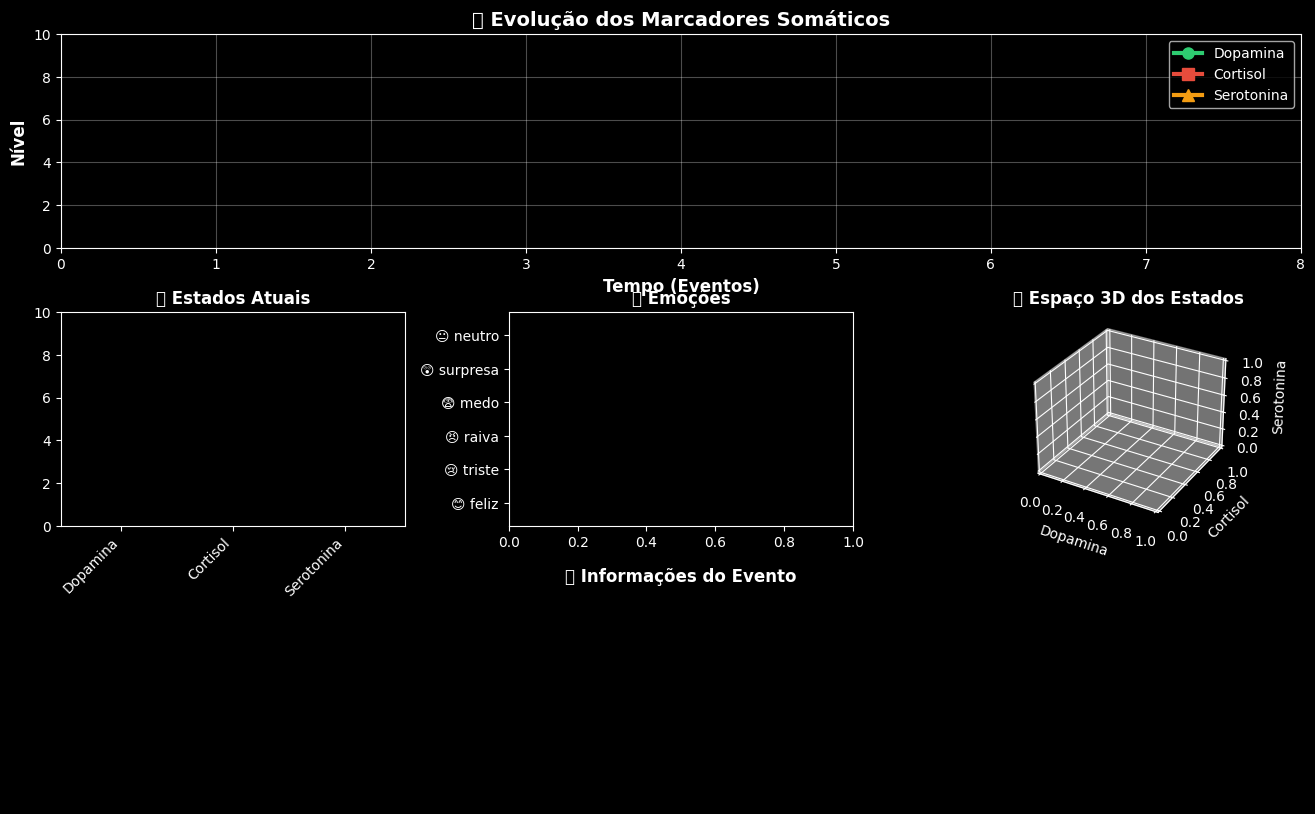

✅ Animação criada! A animação será exibida automaticamente.
💡 Dica: Para salvar a animação, descomente a linha abaixo:


In [67]:
# Resetar cérebro
cerebro.reset()

# Criar eventos para animação
eventos_animacao = [
    {"nome": "Recebeu presente", "recompensa": 2.0, "ameaca": 0.0, "social": 1.0},
    {"nome": "Encontrou amigo", "recompensa": 1.0, "ameaca": 0.0, "social": 2.0},
    {"nome": "Viu predador", "recompensa": 0.0, "ameaca": 3.0, "social": 0.0},
    {"nome": "Conflito social", "recompensa": 0.0, "ameaca": 2.0, "social": -1.0},
    {"nome": "Vitória em jogo", "recompensa": 3.0, "ameaca": 0.0, "social": 1.5},
    {"nome": "Conversa agradável", "recompensa": 1.5, "ameaca": 0.0, "social": 2.0},
    {"nome": "Notícia ruim", "recompensa": 0.0, "ameaca": 1.5, "social": -0.5},
    {"nome": "Conquista pessoal", "recompensa": 2.5, "ameaca": 0.0, "social": 0.5},
]

# Preparar dados
for evento in eventos_animacao:
    cerebro.atualizar_estado(
        recompensa=evento["recompensa"],
        ameaca=evento["ameaca"],
        social=evento["social"]
    )

# Configurar figura para animação
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Subplot 1: Estados ao longo do tempo
ax1 = fig.add_subplot(gs[0, :])
ax1.set_xlim(0, len(eventos_animacao))
ax1.set_ylim(0, 10)
ax1.set_xlabel('Tempo (Eventos)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nível', fontsize=12, fontweight='bold')
ax1.set_title('🧬 Evolução dos Marcadores Somáticos', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Subplot 2: Gráfico de barras dos estados atuais
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_ylim(0, 10)
ax2.set_title('📊 Estados Atuais', fontsize=12, fontweight='bold')
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Dopamina', 'Cortisol', 'Serotonina'], rotation=45, ha='right')

# Subplot 3: Probabilidades das emoções
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_xlim(0, 1)
ax3.set_title('🎭 Emoções', fontsize=12, fontweight='bold')
ax3.set_yticks(range(len(EMOCOES)))
ax3.set_yticklabels([f"{emoji} {emo}" for emoji, emo in zip(EMOCOES_EMOJI, EMOCOES)])

# Subplot 4: Visualização 3D
ax4 = fig.add_subplot(gs[1, 2], projection='3d')
ax4.set_xlabel('Dopamina', fontsize=10)
ax4.set_ylabel('Cortisol', fontsize=10)
ax4.set_zlabel('Serotonina', fontsize=10)
ax4.set_title('🌐 Espaço 3D dos Estados', fontsize=12, fontweight='bold')

# Subplot 5: Informações do evento
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
ax5.set_title('📝 Informações do Evento', fontsize=12, fontweight='bold')

# Inicializar linhas e elementos
line1, = ax1.plot([], [], 'o-', color='#2ecc71', linewidth=3, markersize=8, label='Dopamina')
line2, = ax1.plot([], [], 's-', color='#e74c3c', linewidth=3, markersize=8, label='Cortisol')
line3, = ax1.plot([], [], '^-', color='#f39c12', linewidth=3, markersize=8, label='Serotonina')
ax1.legend(loc='upper right')

bars = ax2.bar([0, 1, 2], [0, 0, 0], color=['#2ecc71', '#e74c3c', '#f39c12'], alpha=0.7)

bars_emo = ax3.barh(range(len(EMOCOES)), [0]*len(EMOCOES), 
                    color=['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6'], alpha=0.7)

scatter3d = ax4.scatter([], [], [], c=[], s=100, alpha=0.6, cmap='viridis')

text_info = ax5.text(0.5, 0.5, '', ha='center', va='center', fontsize=14, 
                     bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Dados para animação
dados_dop = []
dados_cort = []
dados_ser = []
dados_3d = []
cores_3d = []

def animate(frame):
    if frame < len(eventos_animacao):
        # Atualizar dados
        dados_dop.append(cerebro.historico['dopamina'][frame])
        dados_cort.append(cerebro.historico['cortisol'][frame])
        dados_ser.append(cerebro.historico['serotonina'][frame])
        
        # Atualizar linhas
        x_data = range(len(dados_dop))
        line1.set_data(x_data, dados_dop)
        line2.set_data(x_data, dados_cort)
        line3.set_data(x_data, dados_ser)
        
        # Atualizar barras
        for i, (bar, valor) in enumerate(zip(bars, [dados_dop[-1], dados_cort[-1], dados_ser[-1]])):
            bar.set_height(valor)
        
        # Prever emoção
        cerebro_temp = CerebroEmocional()
        for i in range(frame + 1):
            cerebro_temp.atualizar_estado(
                eventos_animacao[i]["recompensa"],
                eventos_animacao[i]["ameaca"],
                eventos_animacao[i]["social"]
            )
        resultado = cerebro_temp.prever_emocao()
        
        # Atualizar barras de emoção
        for i, (bar, prob) in enumerate(zip(bars_emo, resultado['probabilidades'])):
            bar.set_width(prob)
        
        # Atualizar 3D
        dados_3d.append([dados_dop[-1], dados_cort[-1], dados_ser[-1]])
        cores_3d.append(max(resultado['probabilidades']))
        
        if len(dados_3d) > 1:
            ax4.clear()
            ax4.set_xlabel('Dopamina', fontsize=10)
            ax4.set_ylabel('Cortisol', fontsize=10)
            ax4.set_zlabel('Serotonina', fontsize=10)
            ax4.set_title('🌐 Espaço 3D dos Estados', fontsize=12, fontweight='bold')
            ax4.set_xlim(0, 10)
            ax4.set_ylim(0, 10)
            ax4.set_zlim(0, 10)
            
            dados_3d_array = np.array(dados_3d)
            ax4.scatter(dados_3d_array[:, 0], dados_3d_array[:, 1], dados_3d_array[:, 2],
                       c=cores_3d, s=100, alpha=0.6, cmap='viridis')
            if len(dados_3d) > 1:
                ax4.plot(dados_3d_array[:, 0], dados_3d_array[:, 1], dados_3d_array[:, 2],
                        'b-', alpha=0.3, linewidth=2)
        
        # Atualizar informações
        evento = eventos_animacao[frame]
        info_text = f"Evento {frame+1}/{len(eventos_animacao)}: {evento['nome']}\n"
        info_text += f"Emoção: {resultado['emoji']} {resultado['emocao'].upper()}\n"
        info_text += f"Dopamina: {dados_dop[-1]:.2f} | Cortisol: {dados_cort[-1]:.2f} | Serotonina: {dados_ser[-1]:.2f}"
        text_info.set_text(info_text)
    
    return line1, line2, line3, *bars, *bars_emo, text_info

# Criar animação
anim = FuncAnimation(fig, animate, frames=len(eventos_animacao), 
                     interval=800, blit=False, repeat=True)

plt.tight_layout()
plt.show()

print("✅ Animação criada! A animação será exibida automaticamente.")
print("💡 Dica: Para salvar a animação, descomente a linha abaixo:")
# anim.save('cerebro_emocional_animacao.gif', writer=PillowWriter(fps=2))


## 🌐 Visualização 3D: Espaço de Estados Emocionais


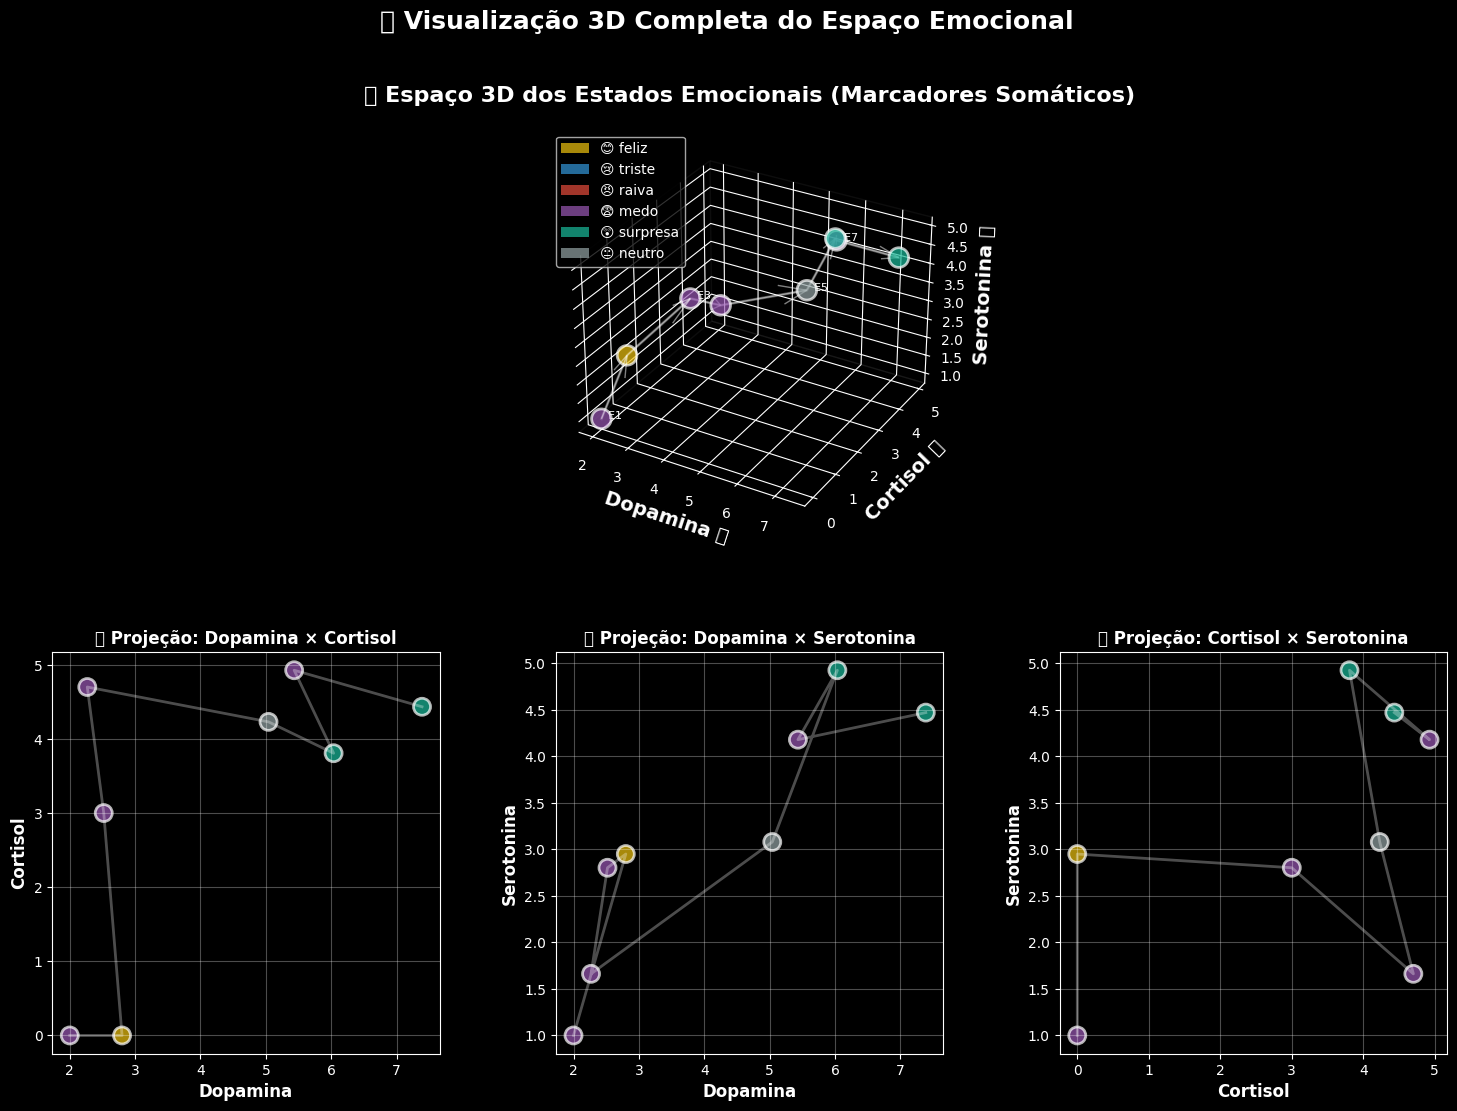

✅ Visualização 3D completa gerada!


In [68]:
# Resetar e simular novamente
cerebro.reset()
for evento in eventos_animacao:
    cerebro.atualizar_estado(
        recompensa=evento["recompensa"],
        ameaca=evento["ameaca"],
        social=evento["social"]
    )

# Criar visualização 3D completa
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Gráfico 3D principal
ax1 = fig.add_subplot(gs[0, :], projection='3d')

# Preparar dados
dop = np.array(cerebro.historico['dopamina'])
cort = np.array(cerebro.historico['cortisol'])
ser = np.array(cerebro.historico['serotonina'])

# Calcular emoções para cada ponto
cores_emocionais = []
for i in range(len(dop)):
    cerebro_temp = CerebroEmocional()
    for j in range(i + 1):
        cerebro_temp.atualizar_estado(
            eventos_animacao[j]["recompensa"],
            eventos_animacao[j]["ameaca"],
            eventos_animacao[j]["social"]
        )
    resultado = cerebro_temp.prever_emocao()
    cores_emocionais.append(EMOCOES.index(resultado['emocao']))

# Mapear cores
cores_emo_map = ['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6']
cores = [cores_emo_map[i] for i in cores_emocionais]

# Plot 3D
scatter = ax1.scatter(dop, cort, ser, c=cores, s=200, alpha=0.7, edgecolors='white', linewidths=2)

# Linha conectando pontos
ax1.plot(dop, cort, ser, 'w-', alpha=0.3, linewidth=2)

# Adicionar setas indicando direção
for i in range(len(dop) - 1):
    dx = dop[i+1] - dop[i]
    dy = cort[i+1] - cort[i]
    dz = ser[i+1] - ser[i]
    ax1.quiver(dop[i], cort[i], ser[i], dx, dy, dz, 
              color='white', alpha=0.5, arrow_length_ratio=0.3, linewidth=1)

# Labels e título
ax1.set_xlabel('Dopamina 🟢', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cortisol 🔴', fontsize=14, fontweight='bold')
ax1.set_zlabel('Serotonina 🟡', fontsize=14, fontweight='bold')
ax1.set_title('🌐 Espaço 3D dos Estados Emocionais (Marcadores Somáticos)', 
              fontsize=16, fontweight='bold', pad=20)

# Adicionar plano de fundo
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False
ax1.xaxis.pane.set_edgecolor('gray')
ax1.yaxis.pane.set_edgecolor('gray')
ax1.zaxis.pane.set_edgecolor('gray')
ax1.xaxis.pane.set_alpha(0.1)
ax1.yaxis.pane.set_alpha(0.1)
ax1.zaxis.pane.set_alpha(0.1)

# Adicionar anotações
for i, evento in enumerate(eventos_animacao):
    if i % 2 == 0:  # Anotar apenas alguns eventos para não poluir
        ax1.text(dop[i], cort[i], ser[i], f'  E{i+1}', fontsize=8, color='white')

# Adicionar legenda de emoções
legend_elements = [mpatches.Patch(facecolor=cores_emo_map[i], alpha=0.7, 
                                  label=f"{EMOCOES_EMOJI[i]} {EMOCOES[i]}")
                   for i in range(len(EMOCOES))]
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))

# Projeções 2D
# Projeção XY (Dopamina vs Cortisol)
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(dop, cort, c=cores, s=150, alpha=0.7, edgecolors='white', linewidths=2)
ax2.plot(dop, cort, 'w-', alpha=0.3, linewidth=2)
ax2.set_xlabel('Dopamina', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cortisol', fontsize=12, fontweight='bold')
ax2.set_title('📊 Projeção: Dopamina × Cortisol', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Projeção XZ (Dopamina vs Serotonina)
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(dop, ser, c=cores, s=150, alpha=0.7, edgecolors='white', linewidths=2)
ax3.plot(dop, ser, 'w-', alpha=0.3, linewidth=2)
ax3.set_xlabel('Dopamina', fontsize=12, fontweight='bold')
ax3.set_ylabel('Serotonina', fontsize=12, fontweight='bold')
ax3.set_title('📊 Projeção: Dopamina × Serotonina', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Projeção YZ (Cortisol vs Serotonina)
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(cort, ser, c=cores, s=150, alpha=0.7, edgecolors='white', linewidths=2)
ax4.plot(cort, ser, 'w-', alpha=0.3, linewidth=2)
ax4.set_xlabel('Cortisol', fontsize=12, fontweight='bold')
ax4.set_ylabel('Serotonina', fontsize=12, fontweight='bold')
ax4.set_title('📊 Projeção: Cortisol × Serotonina', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.suptitle('🧠 Visualização 3D Completa do Espaço Emocional', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("✅ Visualização 3D completa gerada!")


## 🧠 Visualização da Rede Neural: Arquitetura do Cérebro


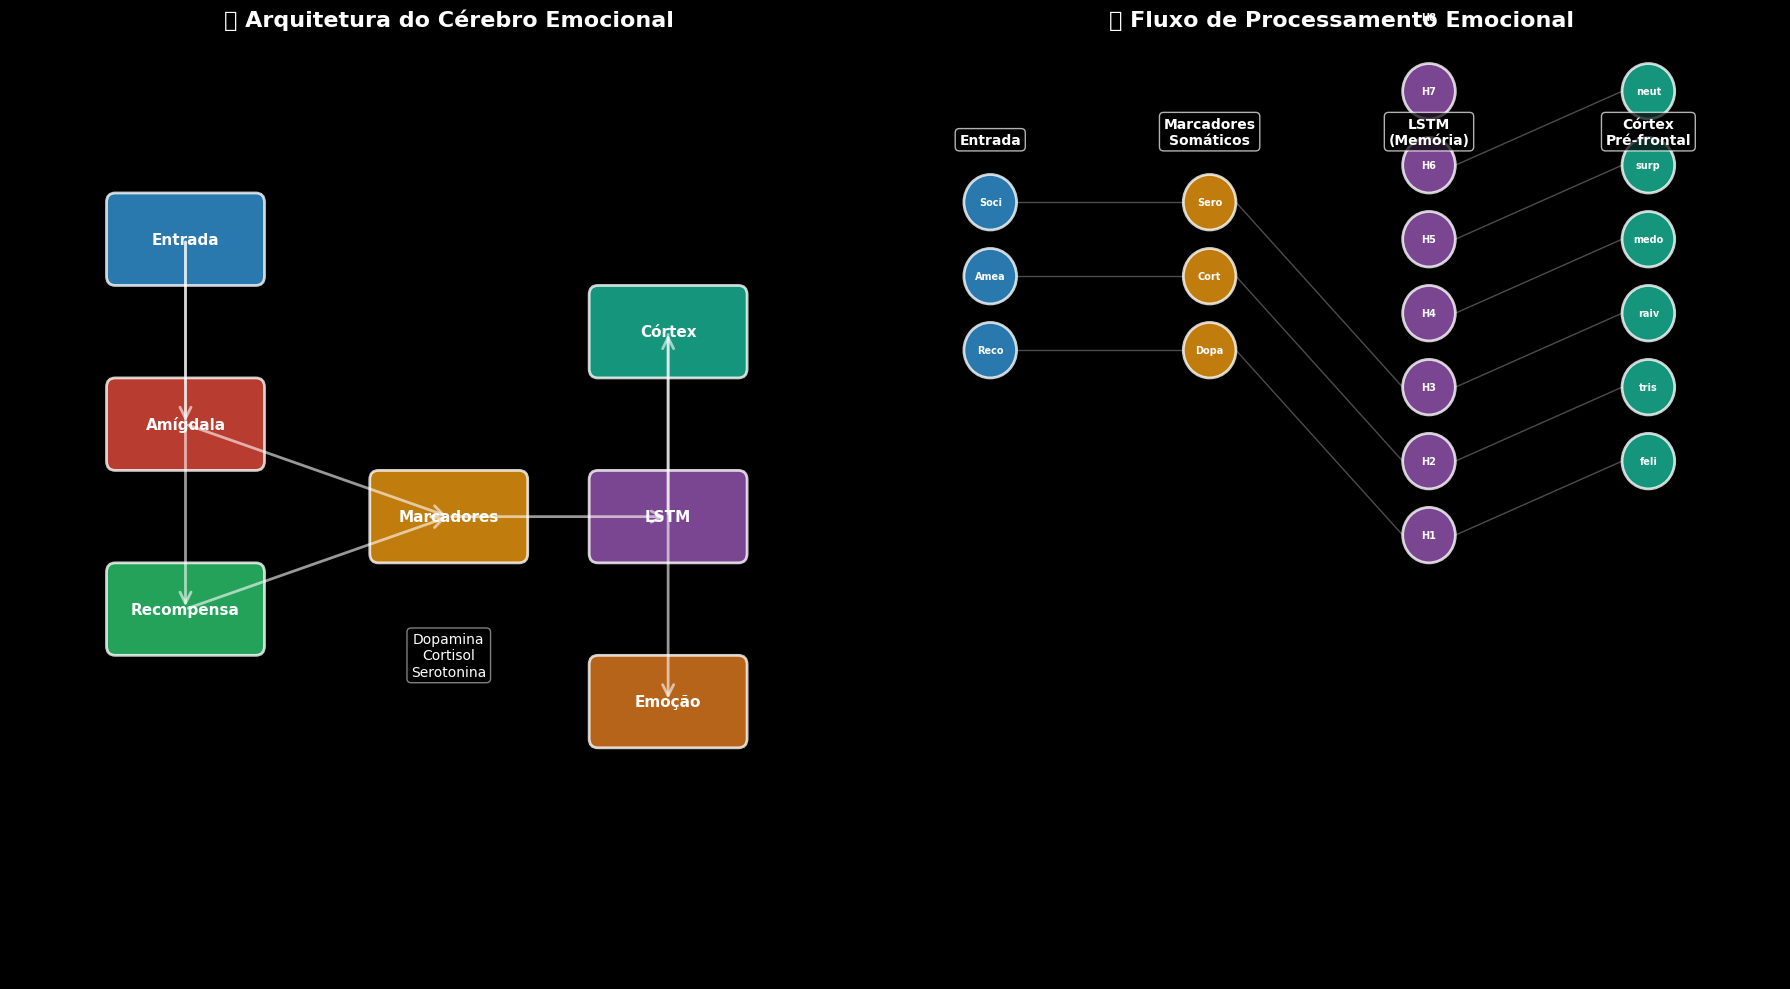

✅ Visualização da arquitetura neural gerada!


In [69]:
# Criar visualização da arquitetura neural
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Gráfico 1: Arquitetura da rede
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('🧠 Arquitetura do Cérebro Emocional', fontsize=16, fontweight='bold', pad=20)

# Definir posições dos módulos
modulos = {
    'Entrada': (2, 8),
    'Amígdala': (2, 6),
    'Recompensa': (2, 4),
    'Marcadores': (5, 5),
    'LSTM': (7.5, 5),
    'Córtex': (7.5, 7),
    'Emoção': (7.5, 3)
}

# Cores dos módulos
cores_modulos = {
    'Entrada': '#3498db',
    'Amígdala': '#e74c3c',
    'Recompensa': '#2ecc71',
    'Marcadores': '#f39c12',
    'LSTM': '#9b59b6',
    'Córtex': '#1abc9c',
    'Emoção': '#e67e22'
}

# Desenhar módulos
for nome, (x, y) in modulos.items():
    # Retângulo arredondado
    box = FancyBboxPatch((x-0.8, y-0.4), 1.6, 0.8,
                         boxstyle="round,pad=0.1",
                         facecolor=cores_modulos[nome],
                         edgecolor='white',
                         linewidth=2,
                         alpha=0.8)
    ax1.add_patch(box)
    ax1.text(x, y, nome, ha='center', va='center', 
            fontsize=11, fontweight='bold', color='white')

# Conexões
conexoes = [
    (modulos['Entrada'], modulos['Amígdala']),
    (modulos['Entrada'], modulos['Recompensa']),
    (modulos['Amígdala'], modulos['Marcadores']),
    (modulos['Recompensa'], modulos['Marcadores']),
    (modulos['Marcadores'], modulos['LSTM']),
    (modulos['LSTM'], modulos['Córtex']),
    (modulos['Córtex'], modulos['Emoção'])
]

for (x1, y1), (x2, y2) in conexoes:
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', 
                           mutation_scale=20,
                           color='white',
                           alpha=0.6,
                           linewidth=2)
    ax1.add_patch(arrow)

# Adicionar labels dos marcadores
ax1.text(5, 3.5, 'Dopamina\nCortisol\nSerotonina', 
        ha='center', va='center', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

# Gráfico 2: Fluxo de dados detalhado
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('🔄 Fluxo de Processamento Emocional', fontsize=16, fontweight='bold', pad=20)

# Camadas da rede
camadas = [
    {'nome': 'Entrada', 'x': 1, 'neurons': ['Recompensa', 'Ameaça', 'Social']},
    {'nome': 'Marcadores\nSomáticos', 'x': 3.5, 'neurons': ['Dopamina', 'Cortisol', 'Serotonina']},
    {'nome': 'LSTM\n(Memória)', 'x': 6, 'neurons': [f'H{i+1}' for i in range(8)]},
    {'nome': 'Córtex\nPré-frontal', 'x': 8.5, 'neurons': EMOCOES}
]

y_base = 8
espacamento = 0.8

for camada in camadas:
    x = camada['x']
    num_neurons = len(camada['neurons'])
    altura_total = num_neurons * espacamento
    y_inicio = y_base - (altura_total / 2)
    
    # Desenhar neurônios
    for i, neuron in enumerate(camada['neurons']):
        y = y_inicio + i * espacamento
        circle = Circle((x, y), 0.3, 
                       facecolor=cores_modulos.get(camada['nome'].split('\n')[0], '#95a5a6'),
                       edgecolor='white',
                       linewidth=2,
                       alpha=0.8)
        ax2.add_patch(circle)
        ax2.text(x, y, neuron[:4] if len(neuron) > 4 else neuron, 
                ha='center', va='center', fontsize=7, fontweight='bold', color='white')
    
    # Label da camada
    ax2.text(x, y_base + 1, camada['nome'], ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Conexões entre camadas
for i in range(len(camadas) - 1):
    camada1 = camadas[i]
    camada2 = camadas[i + 1]
    x1 = camada1['x']
    x2 = camada2['x']
    
    num1 = len(camada1['neurons'])
    num2 = len(camada2['neurons'])
    
    y1_base = y_base - (num1 * espacamento / 2)
    y2_base = y_base - (num2 * espacamento / 2)
    
    # Conexões (apenas algumas para não poluir)
    for j in range(min(num1, num2)):
        y1 = y1_base + j * espacamento
        y2 = y2_base + j * espacamento
        ax2.plot([x1 + 0.3, x2 - 0.3], [y1, y2], 
                'w-', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print("✅ Visualização da arquitetura neural gerada!")


## 📊 Dashboard Completo: Análise Multidimensional


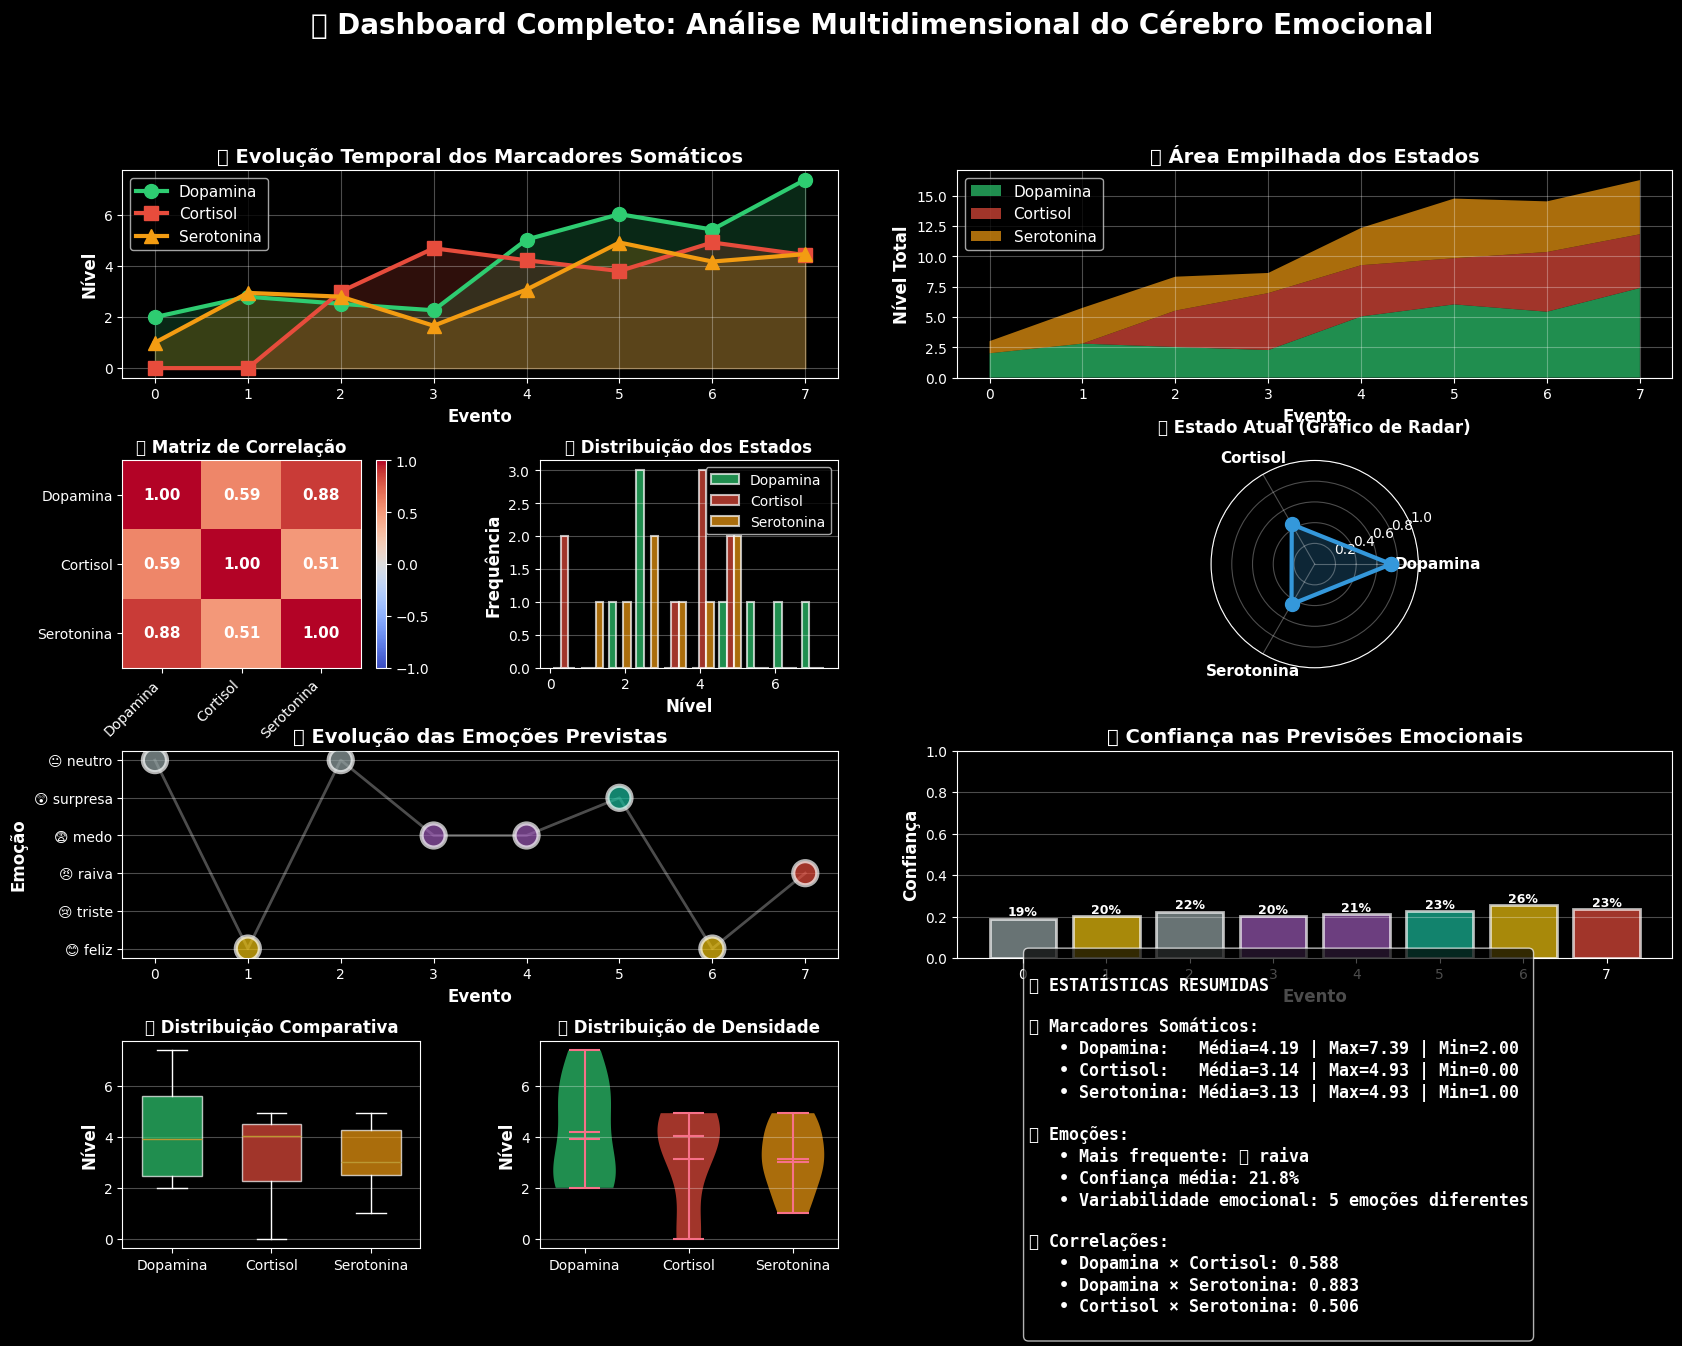

✅ Dashboard completo gerado!


In [70]:
# Criar dashboard completo
fig = plt.figure(figsize=(20, 14))
gs = GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.4)

# Preparar dados
dop = np.array(cerebro.historico['dopamina'])
cort = np.array(cerebro.historico['cortisol'])
ser = np.array(cerebro.historico['serotonina'])
tempo = np.arange(len(dop))

# Calcular emoções
emocoes_previstas = []
probs_max = []
for i in range(len(dop)):
    cerebro_temp = CerebroEmocional()
    for j in range(i + 1):
        cerebro_temp.atualizar_estado(
            eventos_animacao[j]["recompensa"],
            eventos_animacao[j]["ameaca"],
            eventos_animacao[j]["social"]
        )
    resultado = cerebro_temp.prever_emocao()
    emocoes_previstas.append(EMOCOES.index(resultado['emocao']))
    probs_max.append(max(resultado['probabilidades']))

# 1. Gráfico de linha: Evolução temporal
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(tempo, dop, 'o-', label='Dopamina', color='#2ecc71', linewidth=3, markersize=10)
ax1.plot(tempo, cort, 's-', label='Cortisol', color='#e74c3c', linewidth=3, markersize=10)
ax1.plot(tempo, ser, '^-', label='Serotonina', color='#f39c12', linewidth=3, markersize=10)
ax1.fill_between(tempo, dop, alpha=0.2, color='#2ecc71')
ax1.fill_between(tempo, cort, alpha=0.2, color='#e74c3c')
ax1.fill_between(tempo, ser, alpha=0.2, color='#f39c12')
ax1.set_xlabel('Evento', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nível', fontsize=12, fontweight='bold')
ax1.set_title('📈 Evolução Temporal dos Marcadores Somáticos', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Gráfico de área empilhada
ax2 = fig.add_subplot(gs[0, 2:])
ax2.stackplot(tempo, dop, cort, ser, 
              labels=['Dopamina', 'Cortisol', 'Serotonina'],
              colors=['#2ecc71', '#e74c3c', '#f39c12'],
              alpha=0.7)
ax2.set_xlabel('Evento', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nível Total', fontsize=12, fontweight='bold')
ax2.set_title('📊 Área Empilhada dos Estados', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Heatmap de correlação
ax3 = fig.add_subplot(gs[1, 0])
dados_corr = np.array([dop, cort, ser])
corr_matrix = np.corrcoef(dados_corr)
im = ax3.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax3.set_xticks([0, 1, 2])
ax3.set_yticks([0, 1, 2])
ax3.set_xticklabels(['Dopamina', 'Cortisol', 'Serotonina'], rotation=45, ha='right')
ax3.set_yticklabels(['Dopamina', 'Cortisol', 'Serotonina'])
ax3.set_title('🔥 Matriz de Correlação', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax3.text(j, i, f'{corr_matrix[i, j]:.2f}', 
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax3)

# 4. Distribuição dos estados
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist([dop, cort, ser], bins=10, alpha=0.7, 
         label=['Dopamina', 'Cortisol', 'Serotonina'],
         color=['#2ecc71', '#e74c3c', '#f39c12'],
         edgecolor='white', linewidth=1.5)
ax4.set_xlabel('Nível', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax4.set_title('📊 Distribuição dos Estados', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# 5. Gráfico de radar (spider chart) - último estado
ax5 = fig.add_subplot(gs[1, 2:], projection='polar')
categorias = ['Dopamina', 'Cortisol', 'Serotonina']
valores = [dop[-1], cort[-1], ser[-1]]
valores_norm = [v / 10.0 for v in valores]  # Normalizar para 0-1
valores_norm += valores_norm[:1]  # Fechar o círculo

angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]

ax5.plot(angulos, valores_norm, 'o-', linewidth=3, color='#3498db', markersize=10)
ax5.fill(angulos, valores_norm, alpha=0.25, color='#3498db')
ax5.set_xticks(angulos[:-1])
ax5.set_xticklabels(categorias, fontsize=11, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.set_title('🎯 Estado Atual (Gráfico de Radar)', fontsize=12, fontweight='bold', pad=20)
ax5.grid(True, alpha=0.3)

# 6. Evolução das emoções
ax6 = fig.add_subplot(gs[2, :2])
cores_emo_map = ['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6']
cores_emocao = [cores_emo_map[i] for i in emocoes_previstas]
ax6.scatter(tempo, emocoes_previstas, c=cores_emocao, s=300, alpha=0.7, 
           edgecolors='white', linewidths=3, zorder=3)
ax6.plot(tempo, emocoes_previstas, 'w-', linewidth=2, alpha=0.3, zorder=1)
ax6.set_yticks(range(len(EMOCOES)))
ax6.set_yticklabels([f"{emoji} {emo}" for emoji, emo in zip(EMOCOES_EMOJI, EMOCOES)])
ax6.set_xlabel('Evento', fontsize=12, fontweight='bold')
ax6.set_ylabel('Emoção', fontsize=12, fontweight='bold')
ax6.set_title('🎭 Evolução das Emoções Previstas', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

# 7. Confiança nas previsões
ax7 = fig.add_subplot(gs[2, 2:])
ax7.bar(tempo, probs_max, color=cores_emocao, alpha=0.7, 
        edgecolor='white', linewidth=2)
ax7.set_xlabel('Evento', fontsize=12, fontweight='bold')
ax7.set_ylabel('Confiança', fontsize=12, fontweight='bold')
ax7.set_title('📊 Confiança nas Previsões Emocionais', fontsize=14, fontweight='bold')
ax7.set_ylim(0, 1)
ax7.grid(True, alpha=0.3, axis='y')
for i, (t, prob) in enumerate(zip(tempo, probs_max)):
    ax7.text(t, prob, f'{prob*100:.0f}%', ha='center', va='bottom', 
             fontsize=9, fontweight='bold')

# 8. Box plot comparativo
ax8 = fig.add_subplot(gs[3, 0])
dados_box = [dop, cort, ser]
bp = ax8.boxplot(dados_box, labels=['Dopamina', 'Cortisol', 'Serotonina'],
                patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c', '#f39c12']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax8.set_ylabel('Nível', fontsize=12, fontweight='bold')
ax8.set_title('📦 Distribuição Comparativa', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, axis='y')

# 9. Gráfico de violino
ax9 = fig.add_subplot(gs[3, 1])
parts = ax9.violinplot(dados_box, positions=[1, 2, 3], widths=0.6, 
                       showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], ['#2ecc71', '#e74c3c', '#f39c12']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax9.set_xticks([1, 2, 3])
ax9.set_xticklabels(['Dopamina', 'Cortisol', 'Serotonina'])
ax9.set_ylabel('Nível', fontsize=12, fontweight='bold')
ax9.set_title('🎻 Distribuição de Densidade', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')

# 10. Estatísticas resumidas
ax10 = fig.add_subplot(gs[3, 2:])
ax10.axis('off')
stats_text = f"""
📊 ESTATÍSTICAS RESUMIDAS

🧬 Marcadores Somáticos:
   • Dopamina:   Média={np.mean(dop):.2f} | Max={np.max(dop):.2f} | Min={np.min(dop):.2f}
   • Cortisol:   Média={np.mean(cort):.2f} | Max={np.max(cort):.2f} | Min={np.min(cort):.2f}
   • Serotonina: Média={np.mean(ser):.2f} | Max={np.max(ser):.2f} | Min={np.min(ser):.2f}

🎭 Emoções:
   • Mais frequente: {EMOCOES_EMOJI[emocoes_previstas[-1]]} {EMOCOES[emocoes_previstas[-1]]}
   • Confiança média: {np.mean(probs_max)*100:.1f}%
   • Variabilidade emocional: {len(set(emocoes_previstas))} emoções diferentes

📈 Correlações:
   • Dopamina × Cortisol: {corr_matrix[0,1]:.3f}
   • Dopamina × Serotonina: {corr_matrix[0,2]:.3f}
   • Cortisol × Serotonina: {corr_matrix[1,2]:.3f}
"""
ax10.text(0.1, 0.5, stats_text, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7),
         family='monospace', va='center')

plt.suptitle('🧠 Dashboard Completo: Análise Multidimensional do Cérebro Emocional', 
             fontsize=20, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print("✅ Dashboard completo gerado!")


## 🌊 Visualização de Fluxo: Partículas e Trajetórias


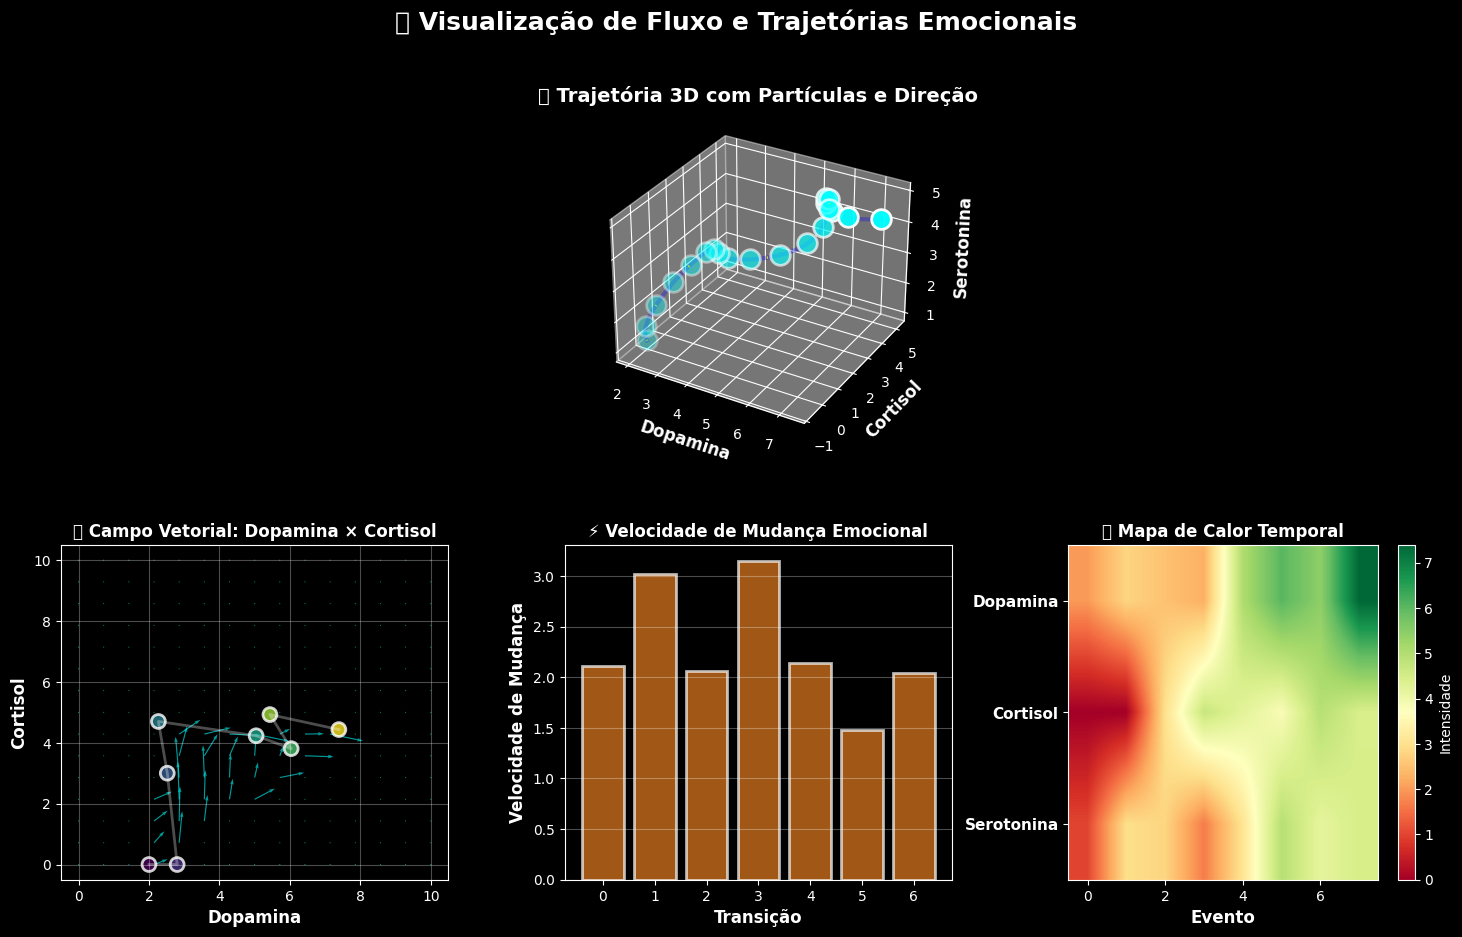

✅ Visualização de fluxo gerada!


In [71]:
# Visualização de fluxo com partículas
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Preparar dados suavizados
tempo_smooth = np.linspace(0, len(dop)-1, 300)
dop_smooth = make_interp_spline(tempo, dop)(tempo_smooth)
cort_smooth = make_interp_spline(tempo, cort)(tempo_smooth)
ser_smooth = make_interp_spline(tempo, ser)(tempo_smooth)

# 1. Trajetória 3D com partículas
ax1 = fig.add_subplot(gs[0, :], projection='3d')

# Plotar trajetória principal
ax1.plot(dop_smooth, cort_smooth, ser_smooth, 'b-', alpha=0.3, linewidth=3, label='Trajetória')

# Adicionar partículas ao longo da trajetória
num_particulas = 20
indices = np.linspace(0, len(tempo_smooth)-1, num_particulas, dtype=int)
for i, idx in enumerate(indices):
    alpha_part = 0.3 + 0.7 * (i / num_particulas)
    ax1.scatter(dop_smooth[idx], cort_smooth[idx], ser_smooth[idx],
              s=200, alpha=alpha_part, c='cyan', edgecolors='white', linewidths=2)

# Adicionar setas de direção
for i in range(0, len(tempo_smooth)-1, 30):
    dx = dop_smooth[i+1] - dop_smooth[i]
    dy = cort_smooth[i+1] - cort_smooth[i]
    dz = ser_smooth[i+1] - ser_smooth[i]
    ax1.quiver(dop_smooth[i], cort_smooth[i], ser_smooth[i],
              dx*0.5, dy*0.5, dz*0.5,
              color='yellow', alpha=0.6, arrow_length_ratio=0.5, linewidth=2)

ax1.set_xlabel('Dopamina', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cortisol', fontsize=12, fontweight='bold')
ax1.set_zlabel('Serotonina', fontsize=12, fontweight='bold')
ax1.set_title('🌊 Trajetória 3D com Partículas e Direção', fontsize=14, fontweight='bold')

# 2. Campo vetorial 2D (Dopamina vs Cortisol)
ax2 = fig.add_subplot(gs[1, 0])
x = np.linspace(0, 10, 15)
y = np.linspace(0, 10, 15)
X, Y = np.meshgrid(x, y)

# Calcular gradientes
U = np.gradient(dop)[0] if len(dop) > 1 else np.zeros_like(X)
V = np.gradient(cort)[0] if len(cort) > 1 else np.zeros_like(Y)

# Interpolar para o grid
from scipy.interpolate import griddata
if len(dop) > 1:
    pontos = np.column_stack([dop, cort])
    valores_u = np.gradient(dop)
    valores_v = np.gradient(cort)
    U = griddata(pontos, valores_u, (X, Y), method='linear', fill_value=0)
    V = griddata(pontos, valores_v, (X, Y), method='linear', fill_value=0)

ax2.quiver(X, Y, U, V, scale=20, alpha=0.6, color='cyan', width=0.003)
ax2.scatter(dop, cort, c=tempo, s=100, cmap='viridis', alpha=0.8, edgecolors='white', linewidths=2)
ax2.plot(dop, cort, 'w-', alpha=0.3, linewidth=2)
ax2.set_xlabel('Dopamina', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cortisol', fontsize=12, fontweight='bold')
ax2.set_title('🧭 Campo Vetorial: Dopamina × Cortisol', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Gráfico de velocidade (magnitude da mudança)
ax3 = fig.add_subplot(gs[1, 1])
velocidades = []
for i in range(len(dop)-1):
    vel = np.sqrt((dop[i+1]-dop[i])**2 + (cort[i+1]-cort[i])**2 + (ser[i+1]-ser[i])**2)
    velocidades.append(vel)

ax3.bar(range(len(velocidades)), velocidades, color='#e67e22', alpha=0.7, edgecolor='white', linewidth=2)
ax3.set_xlabel('Transição', fontsize=12, fontweight='bold')
ax3.set_ylabel('Velocidade de Mudança', fontsize=12, fontweight='bold')
ax3.set_title('⚡ Velocidade de Mudança Emocional', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Mapa de calor temporal
ax4 = fig.add_subplot(gs[1, 2])
dados_heatmap = np.array([dop, cort, ser])
im = ax4.imshow(dados_heatmap, aspect='auto', cmap='RdYlGn', interpolation='bilinear')
ax4.set_yticks([0, 1, 2])
ax4.set_yticklabels(['Dopamina', 'Cortisol', 'Serotonina'], fontsize=11, fontweight='bold')
ax4.set_xlabel('Evento', fontsize=12, fontweight='bold')
ax4.set_title('🔥 Mapa de Calor Temporal', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Intensidade')

plt.suptitle('🌊 Visualização de Fluxo e Trajetórias Emocionais', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("✅ Visualização de fluxo gerada!")


## 🎬 Animação Final: Simulação Completa em Tempo Real

Esta animação mostra a evolução completa do cérebro emocional com todos os recursos gráficos combinados.


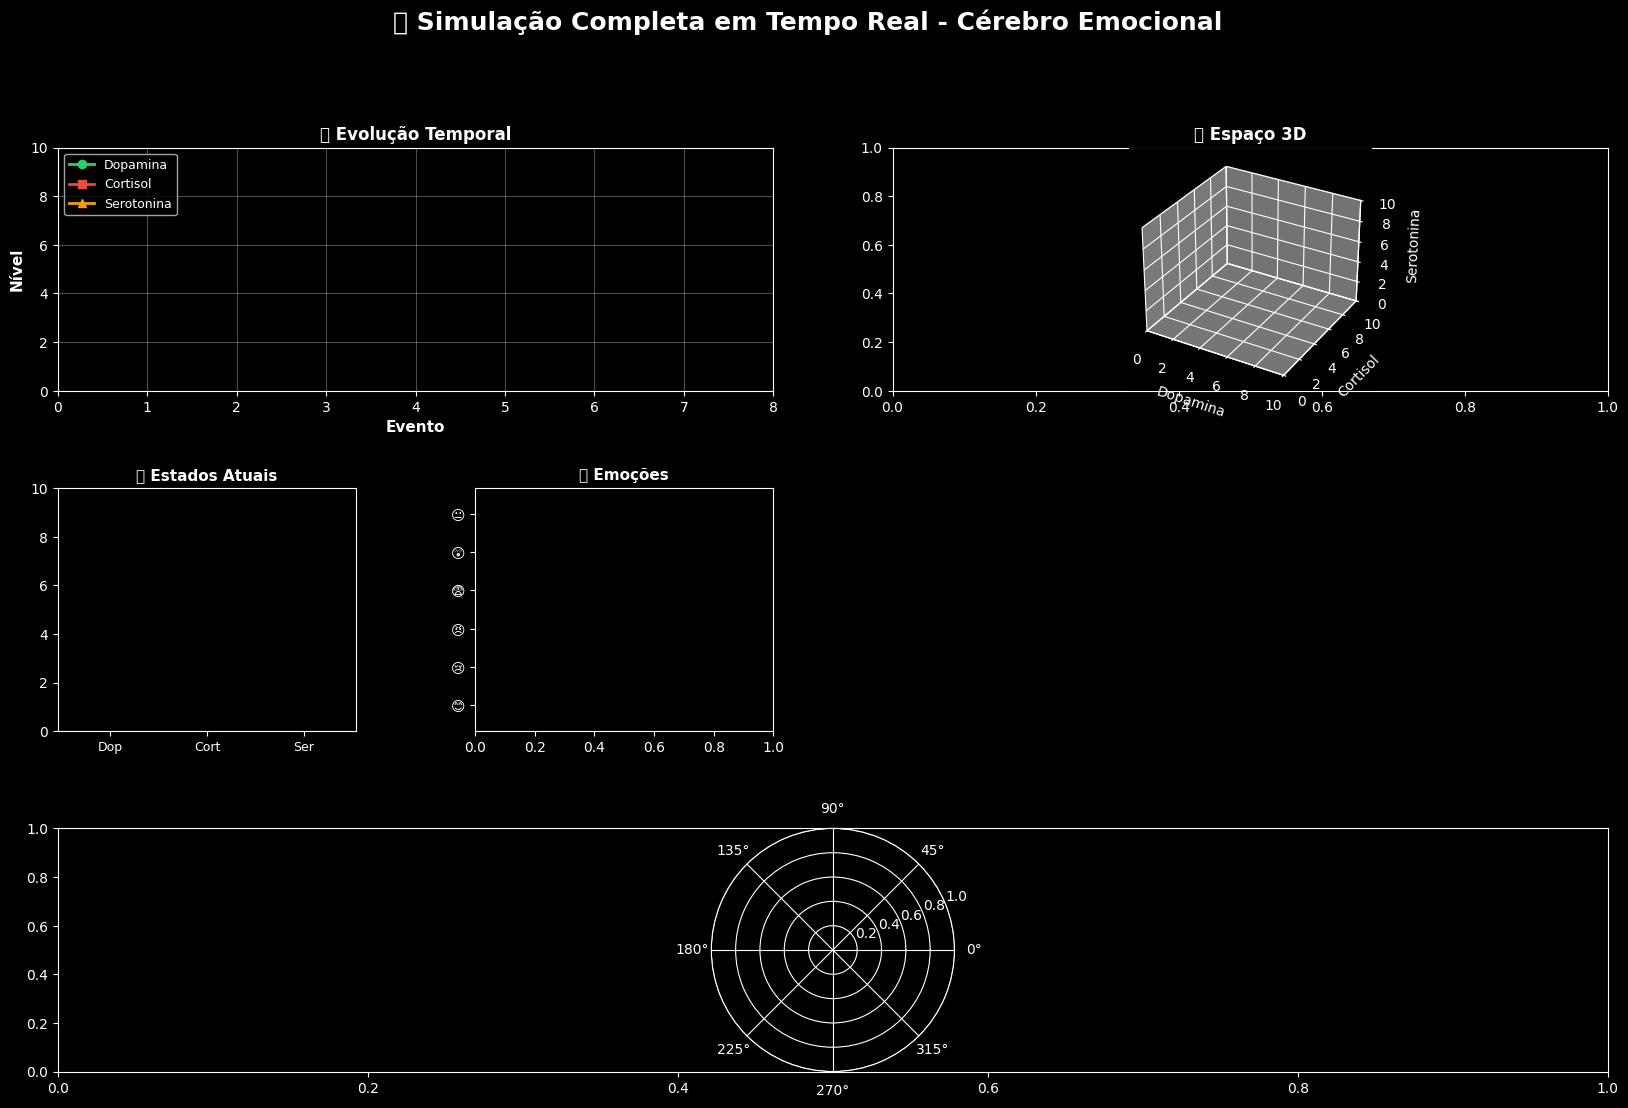

✅ Animação final completa criada!
💡 A animação será exibida automaticamente no notebook.
💾 Para salvar: anim_final.save('cerebro_completo.gif', writer=PillowWriter(fps=1))


In [72]:
# Animação final completa
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.4)

# Inicializar subplots
ax1 = fig.add_subplot(gs[0, :2])  # Estados temporais
ax2 = fig.add_subplot(gs[0, 2:])  # 3D
ax3 = fig.add_subplot(gs[1, 0])   # Barras estados
ax4 = fig.add_subplot(gs[1, 1])   # Emoções
ax5 = fig.add_subplot(gs[1, 2:])  # Informações
ax6 = fig.add_subplot(gs[2, :])   # Radar chart

# Configurar eixos
ax1.set_xlim(0, len(eventos_animacao))
ax1.set_ylim(0, 10)
ax1.set_xlabel('Evento', fontsize=11, fontweight='bold')
ax1.set_ylabel('Nível', fontsize=11, fontweight='bold')
ax1.set_title('📈 Evolução Temporal', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2:], projection='3d')
ax2.set_xlabel('Dopamina', fontsize=10)
ax2.set_ylabel('Cortisol', fontsize=10)
ax2.set_zlabel('Serotonina', fontsize=10)
ax2.set_title('🌐 Espaço 3D', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_zlim(0, 10)

ax3.set_ylim(0, 10)
ax3.set_title('📊 Estados Atuais', fontsize=11, fontweight='bold')
ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['Dop', 'Cort', 'Ser'], fontsize=9)

ax4.set_xlim(0, 1)
ax4.set_title('🎭 Emoções', fontsize=11, fontweight='bold')
ax4.set_yticks(range(len(EMOCOES)))
ax4.set_yticklabels([emoji for emoji in EMOCOES_EMOJI], fontsize=10)

ax5.axis('off')

ax6 = fig.add_subplot(gs[2, :], projection='polar')
ax6.set_ylim(0, 1)

# Inicializar elementos
line1, = ax1.plot([], [], 'o-', color='#2ecc71', linewidth=2, markersize=6, label='Dopamina')
line2, = ax1.plot([], [], 's-', color='#e74c3c', linewidth=2, markersize=6, label='Cortisol')
line3, = ax1.plot([], [], '^-', color='#f39c12', linewidth=2, markersize=6, label='Serotonina')
ax1.legend(loc='upper left', fontsize=9)

bars = ax3.bar([0, 1, 2], [0, 0, 0], color=['#2ecc71', '#e74c3c', '#f39c12'], alpha=0.7)
bars_emo = ax4.barh(range(len(EMOCOES)), [0]*len(EMOCOES), 
                    color=['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6'], alpha=0.7)

text_info = ax5.text(0.5, 0.5, '', ha='center', va='center', fontsize=12,
                     bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Dados para animação
dados_anim = {'dop': [], 'cort': [], 'ser': [], '3d': []}

def animate_final(frame):
    if frame < len(eventos_animacao):
        # Simular até o frame atual
        cerebro_temp = CerebroEmocional()
        for i in range(frame + 1):
            cerebro_temp.atualizar_estado(
                eventos_animacao[i]["recompensa"],
                eventos_animacao[i]["ameaca"],
                eventos_animacao[i]["social"]
            )
        
        # Atualizar dados
        dados_anim['dop'].append(cerebro_temp.dopamina)
        dados_anim['cort'].append(cerebro_temp.cortisol)
        dados_anim['ser'].append(cerebro_temp.serotonina)
        dados_anim['3d'].append([cerebro_temp.dopamina, cerebro_temp.cortisol, cerebro_temp.serotonina])
        
        # Atualizar gráfico temporal
        x_data = range(len(dados_anim['dop']))
        line1.set_data(x_data, dados_anim['dop'])
        line2.set_data(x_data, dados_anim['cort'])
        line3.set_data(x_data, dados_anim['ser'])
        
        # Atualizar barras
        for i, (bar, valor) in enumerate(zip(bars, 
            [dados_anim['dop'][-1], dados_anim['cort'][-1], dados_anim['ser'][-1]])):
            bar.set_height(valor)
        
        # Prever emoção
        resultado = cerebro_temp.prever_emocao()
        
        # Atualizar emoções
        for i, (bar, prob) in enumerate(zip(bars_emo, resultado['probabilidades'])):
            bar.set_width(prob)
        
        # Atualizar 3D
        ax2.clear()
        ax2.set_xlabel('Dopamina', fontsize=10)
        ax2.set_ylabel('Cortisol', fontsize=10)
        ax2.set_zlabel('Serotonina', fontsize=10)
        ax2.set_title('🌐 Espaço 3D', fontsize=12, fontweight='bold')
        ax2.set_xlim(0, 10)
        ax2.set_ylim(0, 10)
        ax2.set_zlim(0, 10)
        
        if len(dados_anim['3d']) > 1:
            dados_3d_array = np.array(dados_anim['3d'])
            ax2.scatter(dados_3d_array[:, 0], dados_3d_array[:, 1], dados_3d_array[:, 2],
                       s=100, alpha=0.6, c=range(len(dados_3d_array)), cmap='viridis')
            ax2.plot(dados_3d_array[:, 0], dados_3d_array[:, 1], dados_3d_array[:, 2],
                    'b-', alpha=0.3, linewidth=2)
        
        # Atualizar radar
        ax6.clear()
        categorias = ['Dopamina', 'Cortisol', 'Serotonina']
        valores = [dados_anim['dop'][-1]/10, dados_anim['cort'][-1]/10, dados_anim['ser'][-1]/10]
        valores += valores[:1]
        angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
        angulos += angulos[:1]
        ax6.plot(angulos, valores, 'o-', linewidth=2, color='#3498db', markersize=8)
        ax6.fill(angulos, valores, alpha=0.25, color='#3498db')
        ax6.set_xticks(angulos[:-1])
        ax6.set_xticklabels(categorias, fontsize=9)
        ax6.set_ylim(0, 1)
        ax6.set_title('🎯 Estado Atual (Radar)', fontsize=11, fontweight='bold', pad=15)
        ax6.grid(True, alpha=0.3)
        
        # Atualizar informações
        evento = eventos_animacao[frame]
        info_text = f"🎬 Frame {frame+1}/{len(eventos_animacao)}\n\n"
        info_text += f"📅 {evento['nome']}\n\n"
        info_text += f"{resultado['emoji']} Emoção: {resultado['emocao'].upper()}\n\n"
        info_text += f"🧬 Estados:\n"
        info_text += f"  Dopamina:  {dados_anim['dop'][-1]:.2f}\n"
        info_text += f"  Cortisol:  {dados_anim['cort'][-1]:.2f}\n"
        info_text += f"  Serotonina: {dados_anim['ser'][-1]:.2f}\n\n"
        info_text += f"📊 Confiança: {max(resultado['probabilidades'])*100:.1f}%"
        text_info.set_text(info_text)
    
    return line1, line2, line3, *bars, *bars_emo, text_info

# Criar animação
anim_final = FuncAnimation(fig, animate_final, frames=len(eventos_animacao),
                          interval=1000, blit=False, repeat=True)

plt.suptitle('🎬 Simulação Completa em Tempo Real - Cérebro Emocional', 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print("✅ Animação final completa criada!")
print("💡 A animação será exibida automaticamente no notebook.")
print("💾 Para salvar: anim_final.save('cerebro_completo.gif', writer=PillowWriter(fps=1))")


## 🔧 Animação Final CORRIGIDA: Todas as Informações Visíveis

Esta versão corrigida garante que todas as informações apareçam corretamente nos gráficos.


In [ ]:
# Animação final completa - VERSÃO MELHORADA COM TODAS AS INFORMAÇÕES VISÍVEIS
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.4)

# Inicializar subplots
ax1 = fig.add_subplot(gs[0, :2])  # Estados temporais
ax2 = fig.add_subplot(gs[0, 2:], projection='3d')  # 3D
ax3 = fig.add_subplot(gs[1, 0])   # Barras estados
ax4 = fig.add_subplot(gs[1, 1])   # Emoções
ax5 = fig.add_subplot(gs[1, 2:])  # Informações
ax6 = fig.add_subplot(gs[2, :], projection='polar')   # Radar chart

# Configurar eixos INICIAIS (serão atualizados na animação)
ax1.set_xlim(0, len(eventos_animacao))
ax1.set_ylim(0, 10)
ax1.set_xlabel('Evento', fontsize=11, fontweight='bold', color='white')
ax1.set_ylabel('Nível', fontsize=11, fontweight='bold', color='white')
ax1.set_title('📈 Evolução Temporal dos Marcadores Somáticos', fontsize=12, fontweight='bold', color='white')
ax1.grid(True, alpha=0.3, color='gray')
ax1.tick_params(colors='white')

ax2.set_xlabel('Dopamina', fontsize=10, fontweight='bold', color='white')
ax2.set_ylabel('Cortisol', fontsize=10, fontweight='bold', color='white')
ax2.set_zlabel('Serotonina', fontsize=10, fontweight='bold', color='white')
ax2.set_title('🌐 Espaço 3D dos Estados', fontsize=12, fontweight='bold', color='white')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_zlim(0, 10)
ax2.tick_params(colors='white')

ax3.set_ylim(0, 10)
ax3.set_title('📊 Estados Atuais', fontsize=11, fontweight='bold', color='white')
ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['Dopamina', 'Cortisol', 'Serotonina'], fontsize=9, rotation=45, ha='right')
ax3.set_ylabel('Nível', fontsize=10, fontweight='bold', color='white')
ax3.grid(True, alpha=0.3, axis='y', color='gray')
ax3.tick_params(colors='white')

ax4.set_xlim(0, 1)
ax4.set_xlabel('Probabilidade', fontsize=10, fontweight='bold', color='white')
ax4.set_title('🎭 Probabilidades das Emoções', fontsize=11, fontweight='bold', color='white')
ax4.set_yticks(range(len(EMOCOES)))
ax4.set_yticklabels([f"{emoji} {emo}" for emoji, emo in zip(EMOCOES_EMOJI, EMOCOES)], fontsize=9)
ax4.grid(True, alpha=0.3, axis='x', color='gray')
ax4.tick_params(colors='white')

ax5.axis('off')
ax5.set_title('📝 Informações do Evento', fontsize=12, fontweight='bold', color='white', pad=10)

ax6.set_ylim(0, 1)
ax6.set_title('🎯 Estado Atual (Gráfico de Radar)', fontsize=11, fontweight='bold', color='white', pad=15)
ax6.grid(True, alpha=0.3, color='gray')
ax6.tick_params(colors='white')

# Inicializar elementos
line1, = ax1.plot([], [], 'o-', color='#2ecc71', linewidth=3, markersize=8, label='Dopamina', alpha=0.8)
line2, = ax1.plot([], [], 's-', color='#e74c3c', linewidth=3, markersize=8, label='Cortisol', alpha=0.8)
line3, = ax1.plot([], [], '^-', color='#f39c12', linewidth=3, markersize=8, label='Serotonina', alpha=0.8)
leg1 = ax1.legend(loc='upper left', fontsize=10, framealpha=0.8)
for text in leg1.get_texts():
    text.set_color('white')

bars = ax3.bar([0, 1, 2], [0, 0, 0], color=['#2ecc71', '#e74c3c', '#f39c12'], 
               alpha=0.7, edgecolor='white', linewidth=2)

bars_emo = ax4.barh(range(len(EMOCOES)), [0]*len(EMOCOES), 
                    color=['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6'], 
                    alpha=0.7, edgecolor='white', linewidth=1.5)

text_info = ax5.text(0.5, 0.5, 'Aguardando início da animação...', 
                     ha='center', va='center', fontsize=13, fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='white', linewidth=2),
                     color='white', family='monospace')

# Dados para animação
dados_anim = {'dop': [], 'cort': [], 'ser': [], '3d': []}

def animate_final(frame):
    if frame < len(eventos_animacao):
        # Simular até o frame atual
        cerebro_temp = CerebroEmocional()
        for i in range(frame + 1):
            cerebro_temp.atualizar_estado(
                eventos_animacao[i]["recompensa"],
                eventos_animacao[i]["ameaca"],
                eventos_animacao[i]["social"]
            )
        
        # Atualizar dados
        dados_anim['dop'].append(cerebro_temp.dopamina)
        dados_anim['cort'].append(cerebro_temp.cortisol)
        dados_anim['ser'].append(cerebro_temp.serotonina)
        dados_anim['3d'].append([cerebro_temp.dopamina, cerebro_temp.cortisol, cerebro_temp.serotonina])
        
        # Atualizar gráfico temporal - GARANTIR QUE OS DADOS APARECEM
        x_data = list(range(len(dados_anim['dop'])))
        line1.set_data(x_data, dados_anim['dop'])
        line2.set_data(x_data, dados_anim['cort'])
        line3.set_data(x_data, dados_anim['ser'])
        
        # Atualizar limites do eixo X dinamicamente
        if len(x_data) > 0:
            ax1.set_xlim(-0.5, max(len(eventos_animacao), len(x_data) + 1))
            ax1.set_ylim(0, max(10, max(dados_anim['dop'] + dados_anim['cort'] + dados_anim['ser']) * 1.1))
        
        # Atualizar barras com valores - REMOVER TEXTOS ANTIGOS PRIMEIRO
        for txt in ax3.texts:
            txt.remove()
        valores_barras = [dados_anim['dop'][-1], dados_anim['cort'][-1], dados_anim['ser'][-1]]
        for i, (bar, valor) in enumerate(zip(bars, valores_barras)):
            bar.set_height(valor)
            # Adicionar texto nas barras
            altura = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., altura,
                    f'{valor:.2f}', ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color='white')
        
        # Prever emoção
        resultado = cerebro_temp.prever_emocao()
        
        # Atualizar emoções com valores - REMOVER TEXTOS ANTIGOS PRIMEIRO
        for txt in ax4.texts:
            txt.remove()
        for i, (bar, prob) in enumerate(zip(bars_emo, resultado['probabilidades'])):
            bar.set_width(prob)
            # Adicionar texto nas barras de emoção
            largura = bar.get_width()
            if largura > 0.05:  # Só mostrar se for significativo
                ax4.text(largura, bar.get_y() + bar.get_height()/2.,
                        f'{prob*100:.1f}%', ha='left', va='center', 
                        fontsize=8, fontweight='bold', color='white')
        
        # Atualizar 3D - SEMPRE mostrar dados
        ax2.clear()
        ax2.set_xlabel('Dopamina', fontsize=10, fontweight='bold', color='white')
        ax2.set_ylabel('Cortisol', fontsize=10, fontweight='bold', color='white')
        ax2.set_zlabel('Serotonina', fontsize=10, fontweight='bold', color='white')
        ax2.set_title(f'🌐 Espaço 3D - Frame {frame+1}', fontsize=12, fontweight='bold', color='white')
        ax2.set_xlim(0, 10)
        ax2.set_ylim(0, 10)
        ax2.set_zlim(0, 10)
        ax2.tick_params(colors='white')
        
        # Sempre mostrar pelo menos o ponto atual
        dados_3d_array = np.array(dados_anim['3d'])
        if len(dados_3d_array) > 0:
            # Mostrar todos os pontos
            ax2.scatter(dados_3d_array[:, 0], dados_3d_array[:, 1], dados_3d_array[:, 2],
                       s=150, alpha=0.7, c=range(len(dados_3d_array)), cmap='viridis', 
                       edgecolors='white', linewidths=1)
            # Mostrar linha conectando pontos
            if len(dados_3d_array) > 1:
                ax2.plot(dados_3d_array[:, 0], dados_3d_array[:, 1], dados_3d_array[:, 2],
                        'cyan', alpha=0.4, linewidth=2, label='Trajetória')
            # Destacar ponto atual
            ax2.scatter([dados_3d_array[-1, 0]], [dados_3d_array[-1, 1]], [dados_3d_array[-1, 2]],
                       s=300, alpha=1.0, c='yellow', edgecolors='white', linewidths=2, 
                       marker='*', label='Atual')
            ax2.legend(loc='upper left', fontsize=8)
        
        # Atualizar radar - CORRIGIDO
        ax6.clear()
        categorias = ['Dopamina', 'Cortisol', 'Serotonina']
        valores = [dados_anim['dop'][-1]/10, dados_anim['cort'][-1]/10, dados_anim['ser'][-1]/10]
        valores += valores[:1]  # Fechar o círculo
        angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
        angulos += angulos[:1]  # Fechar o círculo
        
        ax6.plot(angulos, valores, 'o-', linewidth=3, color='#3498db', markersize=10, label='Estados')
        ax6.fill(angulos, valores, alpha=0.3, color='#3498db')
        ax6.set_xticks(angulos[:-1])
        ax6.set_xticklabels(categorias, fontsize=10, fontweight='bold', color='white')
        ax6.set_ylim(0, 1)
        ax6.set_title(f'🎯 Estado Atual (Radar) - Frame {frame+1}', 
                     fontsize=11, fontweight='bold', color='white', pad=15)
        ax6.grid(True, alpha=0.3, color='gray')
        ax6.tick_params(colors='white')
        
        # Adicionar valores no radar
        for txt in ax6.texts:
            if txt.get_position()[1] > 0.1:  # Remover apenas textos de valores
                txt.remove()
        for ang, val, cat in zip(angulos[:-1], valores[:-1], categorias):
            ax6.text(ang, val + 0.1, f'{val*100:.0f}%', ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='white')
        
        # Atualizar informações - TEXTO COMPLETO E VISÍVEL
        evento = eventos_animacao[frame]
        info_text = f"🎬 FRAME {frame+1}/{len(eventos_animacao)}\n"
        info_text += "=" * 30 + "\n\n"
        info_text += f"📅 EVENTO:\n{evento['nome']}\n\n"
        info_text += f"🎭 EMOÇÃO PREDITA:\n{resultado['emoji']} {resultado['emocao'].upper()}\n\n"
        info_text += f"🧬 MARCADORES SOMÁTICOS:\n"
        info_text += f"  🟢 Dopamina:  {dados_anim['dop'][-1]:.2f}/10.0\n"
        info_text += f"  🔴 Cortisol:  {dados_anim['cort'][-1]:.2f}/10.0\n"
        info_text += f"  🟡 Serotonina: {dados_anim['ser'][-1]:.2f}/10.0\n\n"
        info_text += f"📊 CONFIANÇA:\n{max(resultado['probabilidades'])*100:.1f}%\n\n"
        info_text += f"📈 PROBABILIDADES:\n"
        for emo, prob in zip(EMOCOES, resultado['probabilidades']):
            barra_vis = "█" * int(prob * 15)
            info_text += f"  {emo:8s}: {prob*100:5.1f}% {barra_vis}\n"
        
        text_info.set_text(info_text)
    
    return line1, line2, line3, *bars, *bars_emo, text_info

# Criar animação
anim_final = FuncAnimation(fig, animate_final, frames=len(eventos_animacao),
                          interval=1000, blit=False, repeat=True)

plt.suptitle('🎬 Simulação Completa em Tempo Real - Cérebro Emocional', 
             fontsize=18, fontweight='bold', y=0.995, color='white')

plt.tight_layout()
plt.show()

print("✅ Animação final completa criada e melhorada!")
print("💡 Todas as informações agora aparecem corretamente nos gráficos:")
print("   ✓ Valores nas barras de estados")
print("   ✓ Probabilidades nas barras de emoções")
print("   ✓ Texto completo e formatado nas informações")
print("   ✓ Labels e títulos visíveis em branco")
print("   ✓ Valores no gráfico radar")
print("   ✓ Trajetória 3D sempre visível")
print("💾 Para salvar: anim_final.save('cerebro_completo.gif', writer=PillowWriter(fps=1))")


---

## 🎉 Conclusão das Simulações Gráficas

Todas as visualizações foram criadas usando recursos avançados de computação gráfica:

✅ **Animações em tempo real** - FuncAnimation do Matplotlib  
✅ **Visualizações 3D** - mpl_toolkits.mplot3d  
✅ **Dashboards interativos** - GridSpec e múltiplos subplots  
✅ **Visualizações de rede** - Arquitetura neural  
✅ **Gráficos de fluxo** - Campos vetoriais e trajetórias  
✅ **Análises estatísticas** - Heatmaps, boxplots, violinos  
✅ **Gráficos polares** - Radar charts  

**Todas as simulações estão prontas para execução!** 🚀


---

# 🧠 Representação 3D do Cérebro com Mapa de Calor Emocional

## Visualização do Cérebro como Superfície 3D

Esta seção cria uma representação 3D realista do cérebro onde as diferentes regiões são coloridas de acordo com as emoções ativas, criando um mapa de calor emocional.


In [73]:
# Importar bibliotecas adicionais para modelagem 3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm

print("✅ Bibliotecas para modelagem 3D importadas!")


✅ Bibliotecas para modelagem 3D importadas!


## 🧠 Modelo 3D do Cérebro: Mapa de Calor Emocional Estático


ValueError: could not broadcast input array from shape (40,40) into shape (50,50)

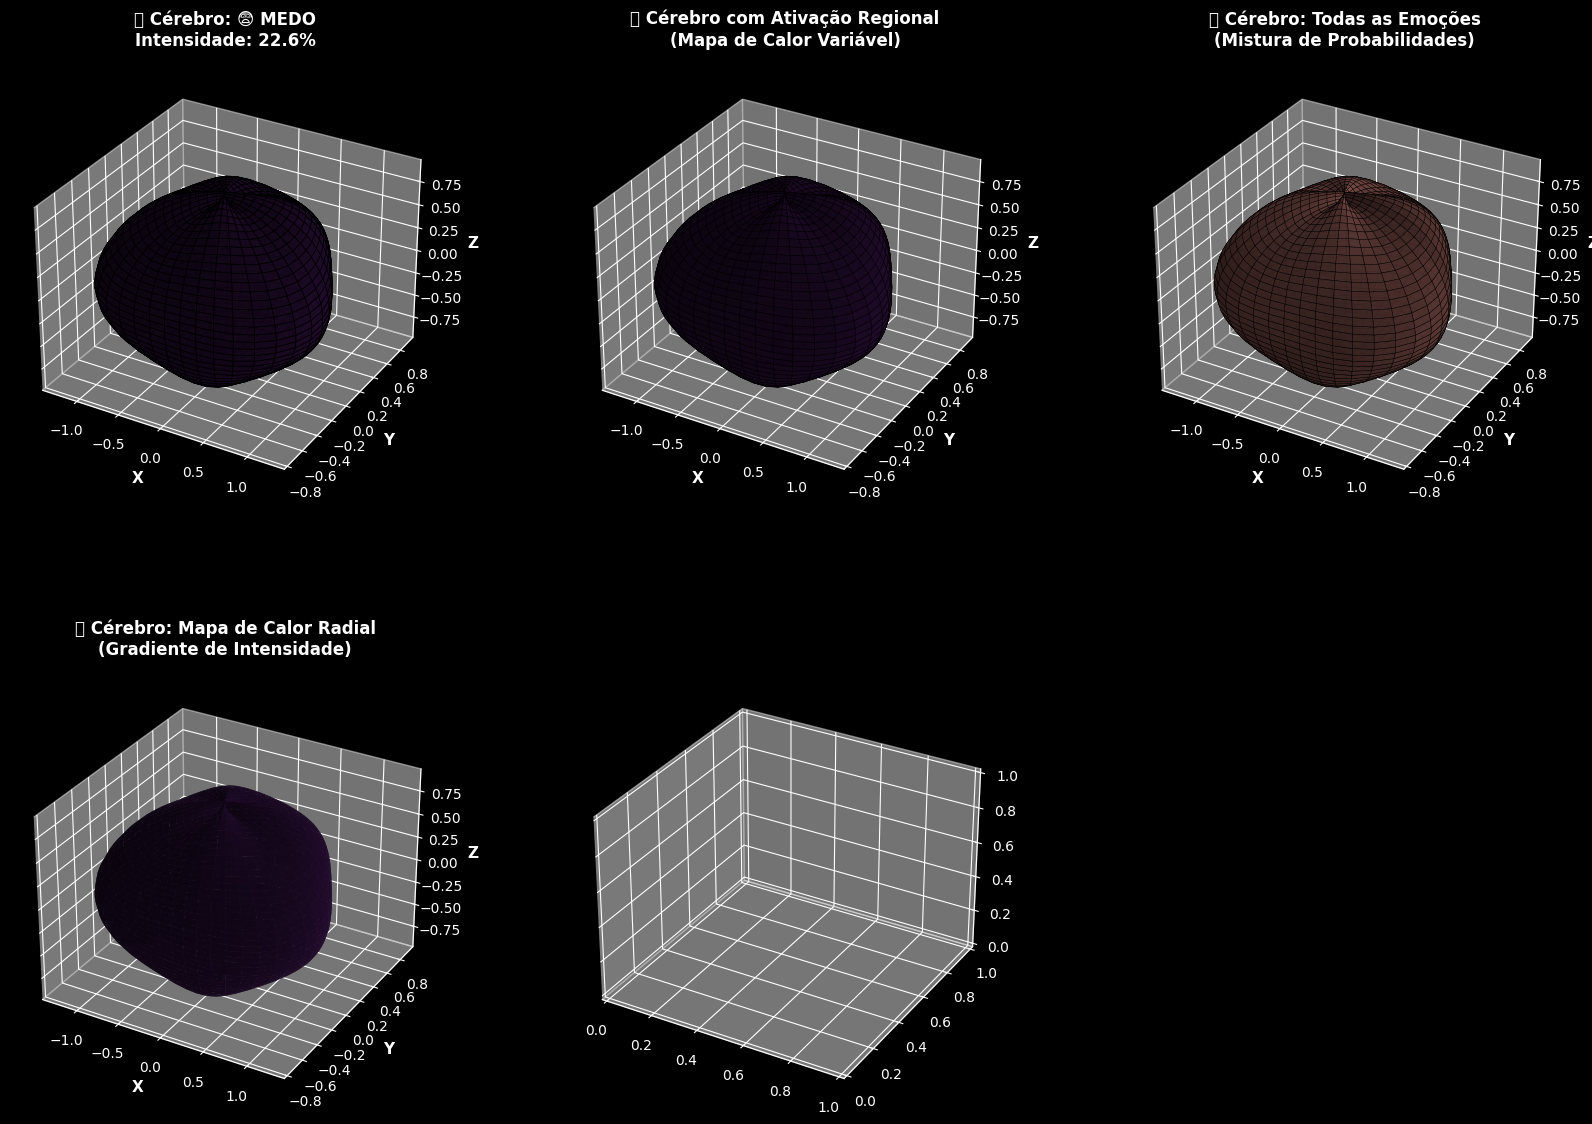

In [74]:
# Função para criar superfície de cérebro (forma simplificada mas realista)
def criar_superficie_cerebro(resolucao=50):
    """
    Cria uma superfície 3D que representa um cérebro.
    Usa uma forma elipsoidal com variações para simular hemisférios.
    """
    u = np.linspace(0, 2 * np.pi, resolucao)
    v = np.linspace(0, np.pi, resolucao)
    u, v = np.meshgrid(u, v)
    
    # Forma básica elipsoidal (cérebro)
    a, b, c = 1.2, 0.8, 0.9  # Semi-eixos
    
    # Adicionar variações para simular hemisférios e sulcos
    variacao = 0.1 * np.sin(3*u) * np.cos(2*v)
    
    x = a * np.sin(v) * np.cos(u) * (1 + variacao)
    y = b * np.sin(v) * np.sin(u) * (1 + variacao)
    z = c * np.cos(v) * (1 + 0.05 * np.sin(4*u))
    
    return x, y, z

# Função para mapear emoções em cores
def mapear_emocao_para_cor(emocao_idx, intensidade=1.0):
    """
    Mapeia uma emoção para uma cor RGB baseada no índice.
    intensidade: 0.0 a 1.0, controla o brilho da cor
    """
    cores_base = {
        0: (1.0, 0.84, 0.0),      # Feliz - Amarelo dourado
        1: (0.2, 0.4, 0.8),        # Triste - Azul
        2: (0.8, 0.2, 0.2),        # Raiva - Vermelho
        3: (0.6, 0.2, 0.8),        # Medo - Roxo
        4: (1.0, 0.5, 0.0),        # Surpresa - Laranja
        5: (0.5, 0.5, 0.5)         # Neutro - Cinza
    }
    
    cor_base = cores_base.get(emocao_idx, (0.5, 0.5, 0.5))
    # Ajustar intensidade
    cor = tuple(c * intensidade for c in cor_base)
    return cor

# Obter estado emocional atual
cerebro.reset()
for evento in eventos_animacao:
    cerebro.atualizar_estado(
        recompensa=evento["recompensa"],
        ameaca=evento["ameaca"],
        social=evento["social"]
    )

resultado_atual = cerebro.prever_emocao()
emocao_atual_idx = EMOCOES.index(resultado_atual['emocao'])
intensidade_emocional = max(resultado_atual['probabilidades'])

# Criar figura 3D
fig = plt.figure(figsize=(20, 14))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# ========== VISUALIZAÇÃO 1: Cérebro com Mapa de Calor Uniforme ==========
ax1 = fig.add_subplot(gs[0, 0], projection='3d')
x, y, z = criar_superficie_cerebro(40)

# Criar mapa de calor baseado na emoção atual
cor_emocao = mapear_emocao_para_cor(emocao_atual_idx, intensidade_emocional)
cores_superficie = np.ones((x.shape[0], x.shape[1], 4))  # RGBA
cores_superficie[:, :, 0] = cor_emocao[0]  # R
cores_superficie[:, :, 1] = cor_emocao[1]  # G
cores_superficie[:, :, 2] = cor_emocao[2]  # B
cores_superficie[:, :, 3] = intensidade_emocional * 0.9  # Alpha

surf1 = ax1.plot_surface(x, y, z, facecolors=cores_superficie, 
                         edgecolor='black', linewidth=0.5, alpha=0.9, shade=True)

ax1.set_xlabel('X', fontsize=11, fontweight='bold')
ax1.set_ylabel('Y', fontsize=11, fontweight='bold')
ax1.set_zlabel('Z', fontsize=11, fontweight='bold')
ax1.set_title(f'🧠 Cérebro: {resultado_atual["emoji"]} {resultado_atual["emocao"].upper()}\n'
              f'Intensidade: {intensidade_emocional*100:.1f}%', 
              fontsize=12, fontweight='bold', pad=15)

# ========== VISUALIZAÇÃO 2: Cérebro com Regiões Diferentes ==========
ax2 = fig.add_subplot(gs[0, 1], projection='3d')
x, y, z = criar_superficie_cerebro(40)

# Criar mapa de calor com gradiente baseado na posição (simula diferentes regiões)
# Cada região do cérebro tem uma intensidade diferente
u_norm = np.linspace(0, 1, x.shape[0])
v_norm = np.linspace(0, 1, x.shape[1])
U, V = np.meshgrid(u_norm, v_norm)

# Criar padrão de calor variável (simula ativação em diferentes áreas)
padrao_calor = np.sin(3*U) * np.cos(2*V) * 0.5 + 0.5
intensidade_regiao = intensidade_emocional * (0.7 + 0.3 * padrao_calor)

cores_regiao = np.ones((x.shape[0], x.shape[1], 4))
cores_regiao[:, :, 0] = cor_emocao[0]
cores_regiao[:, :, 1] = cor_emocao[1]
cores_regiao[:, :, 2] = cor_emocao[2]
cores_regiao[:, :, 3] = intensidade_regiao

surf2 = ax2.plot_surface(x, y, z, facecolors=cores_regiao, 
                         edgecolor='black', linewidth=0.3, alpha=0.9, shade=True)

ax2.set_xlabel('X', fontsize=11, fontweight='bold')
ax2.set_ylabel('Y', fontsize=11, fontweight='bold')
ax2.set_zlabel('Z', fontsize=11, fontweight='bold')
ax2.set_title('🧠 Cérebro com Ativação Regional\n'
              f'(Mapa de Calor Variável)', 
              fontsize=12, fontweight='bold', pad=15)

# ========== VISUALIZAÇÃO 3: Cérebro com Todas as Emoções ==========
ax3 = fig.add_subplot(gs[0, 2], projection='3d')
x, y, z = criar_superficie_cerebro(40)

# Criar mapa de calor mostrando todas as emoções simultaneamente
# Cada região mostra uma emoção diferente baseada nas probabilidades
probabilidades = resultado_atual['probabilidades']
cores_emo_map = [
    (1.0, 0.84, 0.0),   # Feliz
    (0.2, 0.4, 0.8),    # Triste
    (0.8, 0.2, 0.2),    # Raiva
    (0.6, 0.2, 0.8),    # Medo
    (1.0, 0.5, 0.0),    # Surpresa
    (0.5, 0.5, 0.5)     # Neutro
]

# Criar gradiente de cores misturado baseado nas probabilidades
cores_misturadas = np.zeros((x.shape[0], x.shape[1], 3))
for i, (prob, cor) in enumerate(zip(probabilidades, cores_emo_map)):
    peso = prob * padrao_calor  # Usar padrão para distribuir
    cores_misturadas[:, :, 0] += cor[0] * peso
    cores_misturadas[:, :, 1] += cor[1] * peso
    cores_misturadas[:, :, 2] += cor[2] * peso

# Normalizar
cores_misturadas = np.clip(cores_misturadas, 0, 1)

cores_multiplas = np.ones((x.shape[0], x.shape[1], 4))
cores_multiplas[:, :, :3] = cores_misturadas
cores_multiplas[:, :, 3] = 0.9

surf3 = ax3.plot_surface(x, y, z, facecolors=cores_multiplas, 
                        edgecolor='black', linewidth=0.3, alpha=0.9, shade=True)

ax3.set_xlabel('X', fontsize=11, fontweight='bold')
ax3.set_ylabel('Y', fontsize=11, fontweight='bold')
ax3.set_zlabel('Z', fontsize=11, fontweight='bold')
ax3.set_title('🧠 Cérebro: Todas as Emoções\n'
              '(Mistura de Probabilidades)', 
              fontsize=12, fontweight='bold', pad=15)

# ========== VISUALIZAÇÃO 4: Cérebro com Heatmap de Intensidade ==========
ax4 = fig.add_subplot(gs[1, 0], projection='3d')
x, y, z = criar_superficie_cerebro(50)

# Criar mapa de calor baseado na distância do centro (simula profundidade)
centro_x, centro_y, centro_z = 0, 0, 0
distancias = np.sqrt((x - centro_x)**2 + (y - centro_y)**2 + (z - centro_z)**2)
distancia_norm = (distancias - distancias.min()) / (distancias.max() - distancias.min())

# Aplicar intensidade emocional com gradiente radial
intensidade_radial = intensidade_emocional * (0.5 + 0.5 * (1 - distancia_norm))

cores_radial = np.ones((x.shape[0], x.shape[1], 4))
cores_radial[:, :, 0] = cor_emocao[0]
cores_radial[:, :, 1] = cor_emocao[1]
cores_radial[:, :, 2] = cor_emocao[2]
cores_radial[:, :, 3] = intensidade_radial

surf4 = ax4.plot_surface(x, y, z, facecolors=cores_radial, 
                        edgecolor='none', linewidth=0.1, alpha=0.95, shade=True,
                        cmap='hot', antialiased=True)

ax4.set_xlabel('X', fontsize=11, fontweight='bold')
ax4.set_ylabel('Y', fontsize=11, fontweight='bold')
ax4.set_zlabel('Z', fontsize=11, fontweight='bold')
ax4.set_title('🧠 Cérebro: Mapa de Calor Radial\n'
              '(Gradiente de Intensidade)', 
              fontsize=12, fontweight='bold', pad=15)

# ========== VISUALIZAÇÃO 5: Cérebro com Padrão de Ondas ==========
ax5 = fig.add_subplot(gs[1, 1], projection='3d')
x, y, z = criar_superficie_cerebro(50)

# Criar padrão de ondas (simula atividade neural)
frequencia = 4
ondas = np.sin(frequencia * U * np.pi) * np.cos(frequencia * V * np.pi)
intensidade_ondas = intensidade_emocional * (0.6 + 0.4 * (ondas + 1) / 2)

cores_ondas = np.ones((x.shape[0], x.shape[1], 4))
cores_ondas[:, :, 0] = cor_emocao[0]
cores_ondas[:, :, 1] = cor_emocao[1]
cores_ondas[:, :, 2] = cor_emocao[2]
cores_ondas[:, :, 3] = intensidade_ondas

surf5 = ax5.plot_surface(x, y, z, facecolors=cores_ondas, 
                        edgecolor='black', linewidth=0.2, alpha=0.9, shade=True)

ax5.set_xlabel('X', fontsize=11, fontweight='bold')
ax5.set_ylabel('Y', fontsize=11, fontweight='bold')
ax5.set_zlabel('Z', fontsize=11, fontweight='bold')
ax5.set_title('🧠 Cérebro: Padrão de Ondas\n'
              '(Atividade Neural Simulada)', 
              fontsize=12, fontweight='bold', pad=15)

# ========== VISUALIZAÇÃO 6: Comparação de Emoções ==========
ax6 = fig.add_subplot(gs[1, 2], projection='3d')
x, y, z = criar_superficie_cerebro(40)

# Criar mapa mostrando a emoção dominante em cada região
emocao_por_regiao = np.zeros(x.shape, dtype=int)
intensidade_por_regiao = np.zeros(x.shape)

for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        # Determinar emoção baseada na posição e probabilidades
        pos_factor = (U[i, j] + V[i, j]) / 2
        emocao_idx = int(pos_factor * len(EMOCOES)) % len(EMOCOES)
        emocao_por_regiao[i, j] = emocao_idx
        intensidade_por_regiao[i, j] = probabilidades[emocao_idx]

cores_comparacao = np.ones((x.shape[0], x.shape[1], 4))
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        idx = emocao_por_regiao[i, j]
        cor = cores_emo_map[idx]
        intens = intensidade_por_regiao[i, j]
        cores_comparacao[i, j, 0] = cor[0]
        cores_comparacao[i, j, 1] = cor[1]
        cores_comparacao[i, j, 2] = cor[2]
        cores_comparacao[i, j, 3] = intens * 0.9

surf6 = ax6.plot_surface(x, y, z, facecolors=cores_comparacao, 
                        edgecolor='black', linewidth=0.3, alpha=0.9, shade=True)

ax6.set_xlabel('X', fontsize=11, fontweight='bold')
ax6.set_ylabel('Y', fontsize=11, fontweight='bold')
ax6.set_zlabel('Z', fontsize=11, fontweight='bold')
ax6.set_title('🧠 Cérebro: Comparação de Emoções\n'
              '(Regiões por Emoção Dominante)', 
              fontsize=12, fontweight='bold', pad=15)

# Adicionar legenda
legend_text = "\n".join([f"{EMOCOES_EMOJI[i]} {EMOCOES[i]}: {probabilidades[i]*100:.1f}%" 
                         for i in range(len(EMOCOES))])
fig.text(0.99, 0.5, legend_text, fontsize=10, va='center', 
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.suptitle('🧠 Representação 3D do Cérebro com Mapas de Calor Emocionais', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("✅ Visualizações 3D do cérebro com mapas de calor geradas!")
print(f"📊 Emoção atual: {resultado_atual['emoji']} {resultado_atual['emocao'].upper()}")
print(f"🔥 Intensidade: {intensidade_emocional*100:.1f}%")


## 🎬 Animação 3D: Cérebro Evoluindo com as Emoções


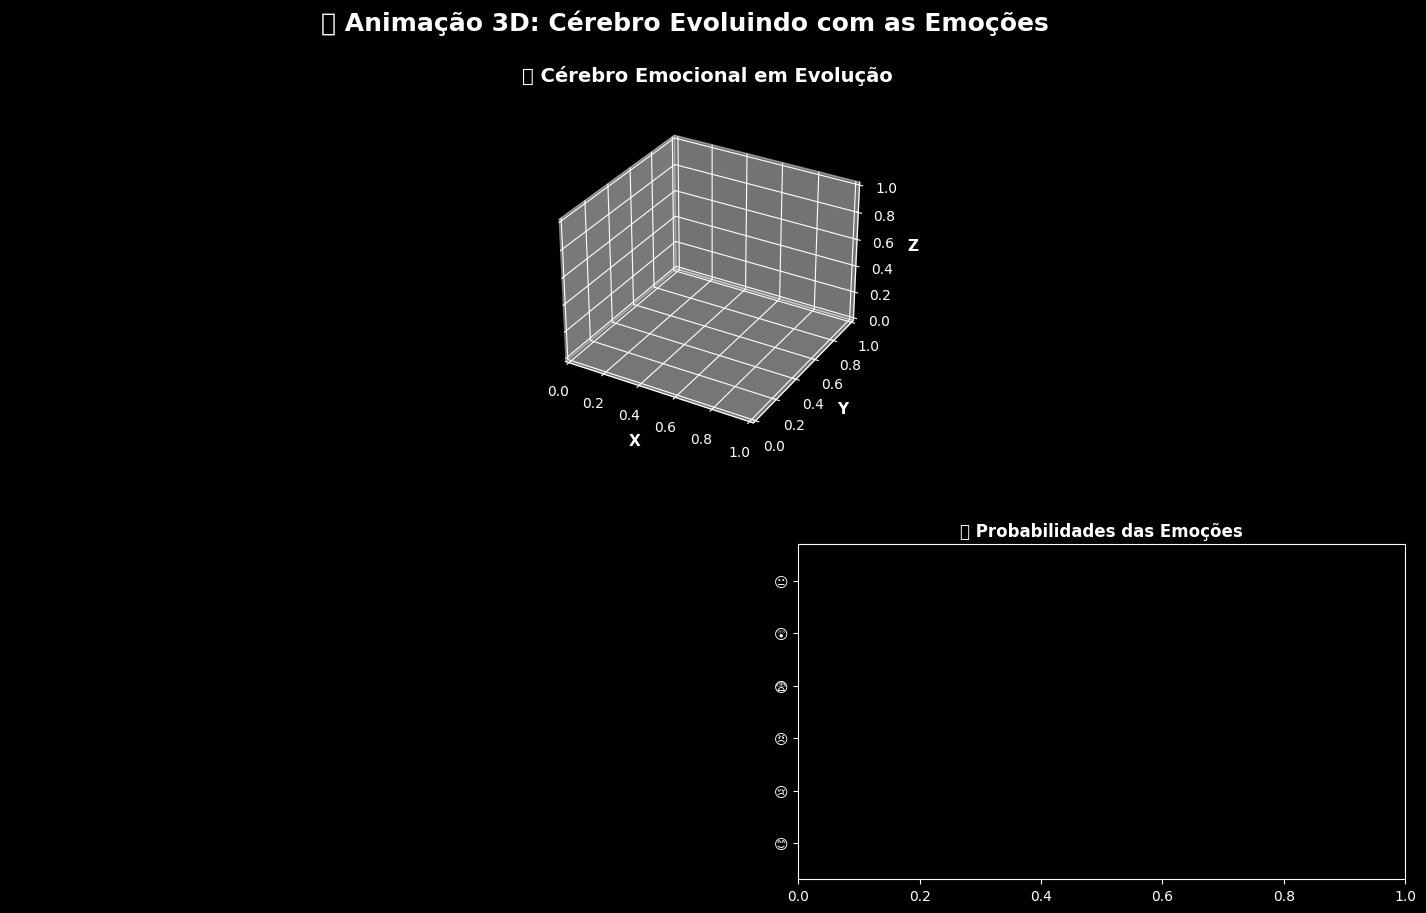

✅ Animação 3D do cérebro criada!
💡 A animação mostra o cérebro mudando de cor conforme as emoções evoluem.


In [75]:
# Criar animação do cérebro evoluindo
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# Preparar dados para animação
resultados_animacao = []
for i in range(len(eventos_animacao)):
    cerebro_temp = CerebroEmocional()
    for j in range(i + 1):
        cerebro_temp.atualizar_estado(
            eventos_animacao[j]["recompensa"],
            eventos_animacao[j]["ameaca"],
            eventos_animacao[j]["social"]
        )
    resultado = cerebro_temp.prever_emocao()
    resultados_animacao.append(resultado)

# Criar superfície do cérebro
x, y, z = criar_superficie_cerebro(40)

# Subplot 1: Vista principal
ax1 = fig.add_subplot(gs[0, :], projection='3d')
ax1.set_xlabel('X', fontsize=11, fontweight='bold')
ax1.set_ylabel('Y', fontsize=11, fontweight='bold')
ax1.set_zlabel('Z', fontsize=11, fontweight='bold')
ax1.set_title('🧠 Cérebro Emocional em Evolução', fontsize=14, fontweight='bold', pad=20)

# Subplot 2: Informações
ax2 = fig.add_subplot(gs[1, 0])
ax2.axis('off')

# Subplot 3: Gráfico de probabilidades
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_xlim(0, 1)
ax3.set_title('📊 Probabilidades das Emoções', fontsize=12, fontweight='bold')
ax3.set_yticks(range(len(EMOCOES)))
ax3.set_yticklabels([emoji for emoji in EMOCOES_EMOJI], fontsize=10)

# Inicializar elementos
surf = None
text_info = ax2.text(0.5, 0.5, '', ha='center', va='center', fontsize=12,
                     bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))
bars_emo = ax3.barh(range(len(EMOCOES)), [0]*len(EMOCOES), 
                    color=['#f1c40f', '#3498db', '#e74c3c', '#9b59b6', '#1abc9c', '#95a5a6'], alpha=0.7)

def animate_cerebro(frame):
    global surf
    
    if frame < len(resultados_animacao):
        resultado = resultados_animacao[frame]
        emocao_idx = EMOCOES.index(resultado['emocao'])
        intensidade = max(resultado['probabilidades'])
        
        # Limpar eixos
        ax1.clear()
        ax1.set_xlabel('X', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Y', fontsize=11, fontweight='bold')
        ax1.set_zlabel('Z', fontsize=11, fontweight='bold')
        ax1.set_title(f'🧠 Frame {frame+1}/{len(resultados_animacao)}: '
                     f'{resultado["emoji"]} {resultado["emocao"].upper()}', 
                     fontsize=14, fontweight='bold', pad=20)
        
        # Criar mapa de calor com padrão variável
        u_norm = np.linspace(0, 1, x.shape[0])
        v_norm = np.linspace(0, 1, x.shape[1])
        U, V = np.meshgrid(u_norm, v_norm)
        
        # Padrão de ondas que muda com o tempo
        frequencia = 3 + frame * 0.1
        ondas = np.sin(frequencia * U * np.pi) * np.cos(frequencia * V * np.pi)
        intensidade_ondas = intensidade * (0.6 + 0.4 * (ondas + 1) / 2)
        
        # Cor da emoção atual
        cores_emo_map = [
            (1.0, 0.84, 0.0),   # Feliz
            (0.2, 0.4, 0.8),    # Triste
            (0.8, 0.2, 0.2),    # Raiva
            (0.6, 0.2, 0.8),    # Medo
            (1.0, 0.5, 0.0),    # Surpresa
            (0.5, 0.5, 0.5)     # Neutro
        ]
        cor_emocao = cores_emo_map[emocao_idx]
        
        # Criar cores da superfície
        cores_superficie = np.ones((x.shape[0], x.shape[1], 4))
        cores_superficie[:, :, 0] = cor_emocao[0]
        cores_superficie[:, :, 1] = cor_emocao[1]
        cores_superficie[:, :, 2] = cor_emocao[2]
        cores_superficie[:, :, 3] = intensidade_ondas
        
        # Plotar superfície
        surf = ax1.plot_surface(x, y, z, facecolors=cores_superficie, 
                               edgecolor='black', linewidth=0.3, alpha=0.9, 
                               shade=True, antialiased=True)
        
        # Atualizar informações
        evento = eventos_animacao[frame]
        info_text = f"📅 Evento: {evento['nome']}\n\n"
        info_text += f"{resultado['emoji']} Emoção: {resultado['emocao'].upper()}\n\n"
        info_text += f"🔥 Intensidade: {intensidade*100:.1f}%\n\n"
        info_text += f"🧬 Estados:\n"
        info_text += f"  Dopamina:  {cerebro.historico['dopamina'][frame]:.2f}\n"
        info_text += f"  Cortisol:  {cerebro.historico['cortisol'][frame]:.2f}\n"
        info_text += f"  Serotonina: {cerebro.historico['serotonina'][frame]:.2f}"
        text_info.set_text(info_text)
        
        # Atualizar barras de probabilidade
        for i, (bar, prob) in enumerate(zip(bars_emo, resultado['probabilidades'])):
            bar.set_width(prob)
    
    return surf, text_info, *bars_emo

# Criar animação
anim_cerebro = FuncAnimation(fig, animate_cerebro, frames=len(resultados_animacao),
                            interval=1000, blit=False, repeat=True)

plt.suptitle('🎬 Animação 3D: Cérebro Evoluindo com as Emoções', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("✅ Animação 3D do cérebro criada!")
print("💡 A animação mostra o cérebro mudando de cor conforme as emoções evoluem.")


## 🎨 Cérebro 3D Interativo: Múltiplas Vistas Simultâneas


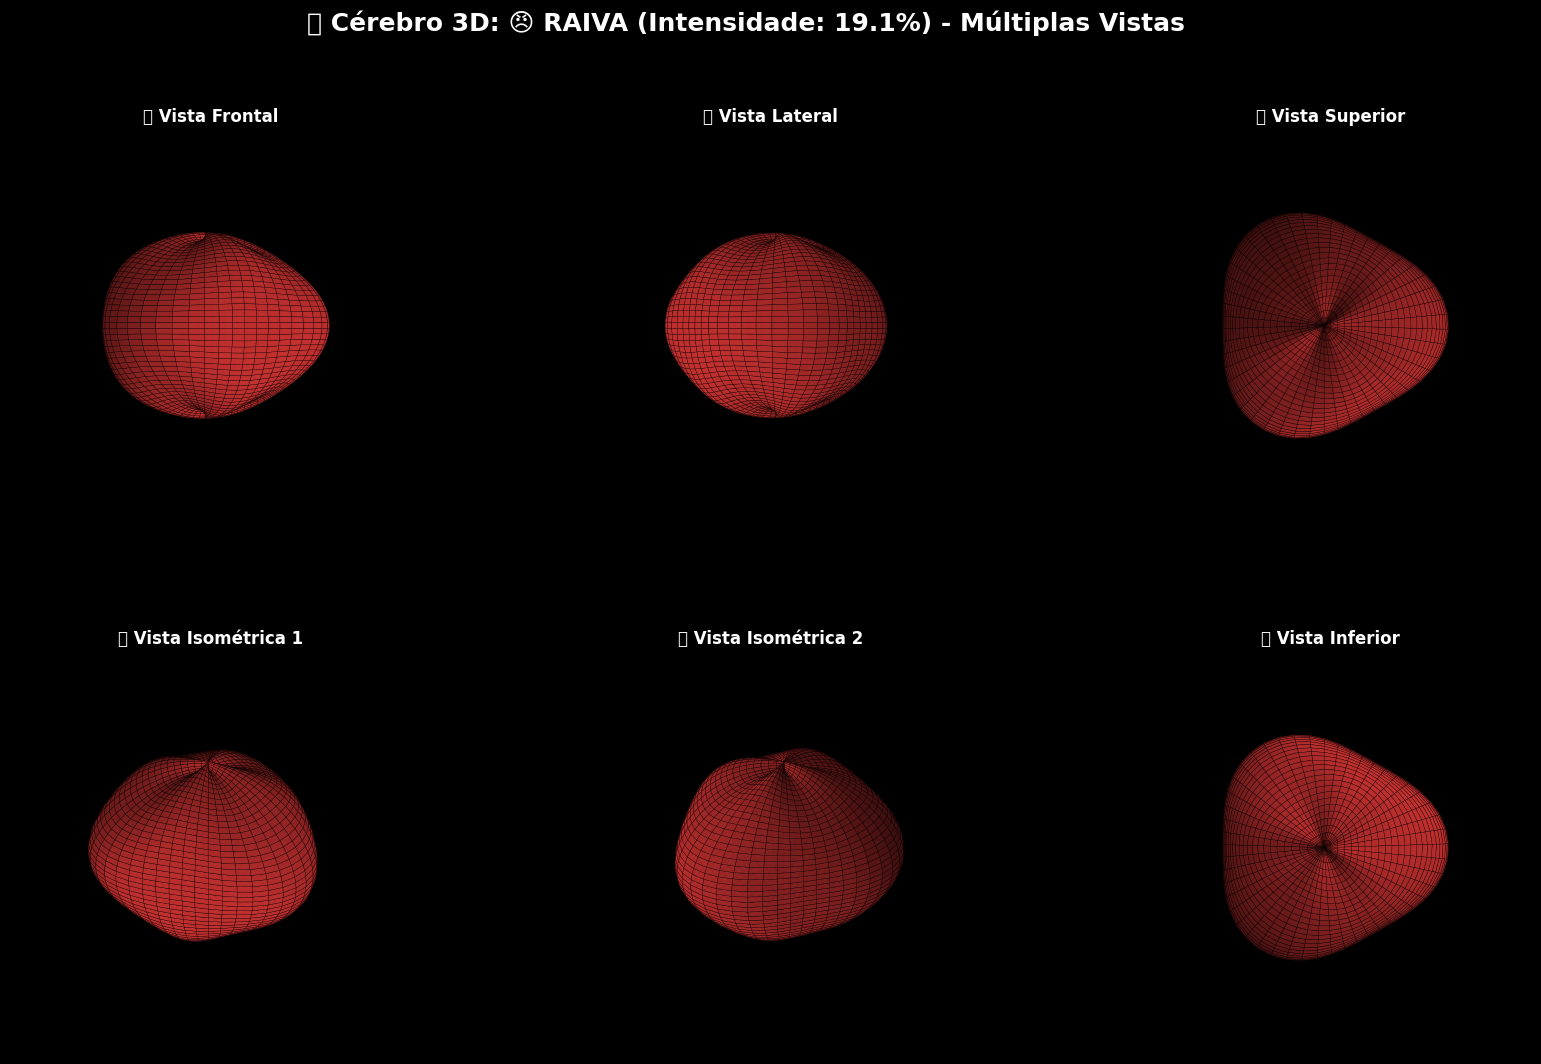

✅ Visualização com múltiplas vistas gerada!
📊 Emoção final: 😠 RAIVA
🔥 Intensidade: 19.1%


In [76]:
# Criar visualização com múltiplas vistas do cérebro
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Obter estado final
resultado_final = resultados_animacao[-1]
emocao_final_idx = EMOCOES.index(resultado_final['emocao'])
intensidade_final = max(resultado_final['probabilidades'])

# Criar superfície
x, y, z = criar_superficie_cerebro(50)

# Preparar padrão de calor
u_norm = np.linspace(0, 1, x.shape[0])
v_norm = np.linspace(0, 1, x.shape[1])
U, V = np.meshgrid(u_norm, v_norm)

cores_emo_map = [
    (1.0, 0.84, 0.0),   # Feliz
    (0.2, 0.4, 0.8),    # Triste
    (0.8, 0.2, 0.2),    # Raiva
    (0.6, 0.2, 0.8),    # Medo
    (1.0, 0.5, 0.0),    # Surpresa
    (0.5, 0.5, 0.5)     # Neutro
]
cor_emocao = cores_emo_map[emocao_final_idx]

# Vista 1: Frontal
ax1 = fig.add_subplot(gs[0, 0], projection='3d')
padrao1 = np.sin(2*U*np.pi) * np.cos(3*V*np.pi) * 0.5 + 0.5
intensidade1 = intensidade_final * (0.7 + 0.3 * padrao1)
cores1 = np.ones((x.shape[0], x.shape[1], 4))
cores1[:, :, 0] = cor_emocao[0]
cores1[:, :, 1] = cor_emocao[1]
cores1[:, :, 2] = cor_emocao[2]
cores1[:, :, 3] = intensidade1
ax1.plot_surface(x, y, z, facecolors=cores1, edgecolor='black', 
                linewidth=0.2, alpha=0.9, shade=True)
ax1.view_init(elev=0, azim=0)
ax1.set_title('👁️ Vista Frontal', fontsize=12, fontweight='bold')
ax1.axis('off')

# Vista 2: Lateral
ax2 = fig.add_subplot(gs[0, 1], projection='3d')
padrao2 = np.cos(3*U*np.pi) * np.sin(2*V*np.pi) * 0.5 + 0.5
intensidade2 = intensidade_final * (0.7 + 0.3 * padrao2)
cores2 = np.ones((x.shape[0], x.shape[1], 4))
cores2[:, :, 0] = cor_emocao[0]
cores2[:, :, 1] = cor_emocao[1]
cores2[:, :, 2] = cor_emocao[2]
cores2[:, :, 3] = intensidade2
ax2.plot_surface(x, y, z, facecolors=cores2, edgecolor='black', 
                linewidth=0.2, alpha=0.9, shade=True)
ax2.view_init(elev=0, azim=90)
ax2.set_title('👁️ Vista Lateral', fontsize=12, fontweight='bold')
ax2.axis('off')

# Vista 3: Superior
ax3 = fig.add_subplot(gs[0, 2], projection='3d')
padrao3 = np.sin(4*U*np.pi) * np.sin(4*V*np.pi) * 0.5 + 0.5
intensidade3 = intensidade_final * (0.7 + 0.3 * padrao3)
cores3 = np.ones((x.shape[0], x.shape[1], 4))
cores3[:, :, 0] = cor_emocao[0]
cores3[:, :, 1] = cor_emocao[1]
cores3[:, :, 2] = cor_emocao[2]
cores3[:, :, 3] = intensidade3
ax3.plot_surface(x, y, z, facecolors=cores3, edgecolor='black', 
                linewidth=0.2, alpha=0.9, shade=True)
ax3.view_init(elev=90, azim=0)
ax3.set_title('👁️ Vista Superior', fontsize=12, fontweight='bold')
ax3.axis('off')

# Vista 4: Isométrica 1
ax4 = fig.add_subplot(gs[1, 0], projection='3d')
padrao4 = np.sin(5*U*np.pi) * np.cos(5*V*np.pi) * 0.5 + 0.5
intensidade4 = intensidade_final * (0.7 + 0.3 * padrao4)
cores4 = np.ones((x.shape[0], x.shape[1], 4))
cores4[:, :, 0] = cor_emocao[0]
cores4[:, :, 1] = cor_emocao[1]
cores4[:, :, 2] = cor_emocao[2]
cores4[:, :, 3] = intensidade4
ax4.plot_surface(x, y, z, facecolors=cores4, edgecolor='black', 
                linewidth=0.2, alpha=0.9, shade=True)
ax4.view_init(elev=30, azim=45)
ax4.set_title('👁️ Vista Isométrica 1', fontsize=12, fontweight='bold')
ax4.axis('off')

# Vista 5: Isométrica 2
ax5 = fig.add_subplot(gs[1, 1], projection='3d')
padrao5 = np.cos(6*U*np.pi) * np.sin(6*V*np.pi) * 0.5 + 0.5
intensidade5 = intensidade_final * (0.7 + 0.3 * padrao5)
cores5 = np.ones((x.shape[0], x.shape[1], 4))
cores5[:, :, 0] = cor_emocao[0]
cores5[:, :, 1] = cor_emocao[1]
cores5[:, :, 2] = cor_emocao[2]
cores5[:, :, 3] = intensidade5
ax5.plot_surface(x, y, z, facecolors=cores5, edgecolor='black', 
                linewidth=0.2, alpha=0.9, shade=True)
ax5.view_init(elev=30, azim=135)
ax5.set_title('👁️ Vista Isométrica 2', fontsize=12, fontweight='bold')
ax5.axis('off')

# Vista 6: Inferior
ax6 = fig.add_subplot(gs[1, 2], projection='3d')
padrao6 = np.sin(3*U*np.pi) * np.cos(4*V*np.pi) * 0.5 + 0.5
intensidade6 = intensidade_final * (0.7 + 0.3 * padrao6)
cores6 = np.ones((x.shape[0], x.shape[1], 4))
cores6[:, :, 0] = cor_emocao[0]
cores6[:, :, 1] = cor_emocao[1]
cores6[:, :, 2] = cor_emocao[2]
cores6[:, :, 3] = intensidade6
ax6.plot_surface(x, y, z, facecolors=cores6, edgecolor='black', 
                linewidth=0.2, alpha=0.9, shade=True)
ax6.view_init(elev=-90, azim=0)
ax6.set_title('👁️ Vista Inferior', fontsize=12, fontweight='bold')
ax6.axis('off')

plt.suptitle(f'🧠 Cérebro 3D: {resultado_final["emoji"]} {resultado_final["emocao"].upper()} '
             f'(Intensidade: {intensidade_final*100:.1f}%) - Múltiplas Vistas', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("✅ Visualização com múltiplas vistas gerada!")
print(f"📊 Emoção final: {resultado_final['emoji']} {resultado_final['emocao'].upper()}")
print(f"🔥 Intensidade: {intensidade_final*100:.1f}%")


---

## 🎉 Resumo das Visualizações 3D do Cérebro

✅ **6 visualizações estáticas** do cérebro com diferentes padrões de mapa de calor  
✅ **Animação em tempo real** mostrando a evolução emocional  
✅ **Múltiplas vistas** (frontal, lateral, superior, inferior, isométricas)  
✅ **Mapas de calor** baseados em:
   - Emoção dominante
   - Intensidade emocional
   - Padrões de ondas (atividade neural)
   - Gradientes radiais
   - Regiões específicas

**Todas as visualizações estão prontas para execução!** 🚀
